# Part A - Stage A - scarping

In [1]:
!pip install selenium
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install torch


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Roni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Roni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Roni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Roni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Roni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Roni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports


In [2]:
# imports

import csv
import re
import time
import random
from dataclasses import asdict, dataclass
from datetime import date, timedelta, datetime

from selenium import webdriver
from selenium.common import InvalidSessionIdException, WebDriverException
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service

## Config


In [3]:
# Config

CITY = "New York"
ADULTS = 2
CHILDREN = 0
ROOMS = 1

TTT_RANGE = range(1, 31)
LOS_RANGE = range(1, 6)

HOTELS_PER_SEARCH = 100
PAGE_SIZE = 25
MAX_PAGES_GUARD = 10

## Data model


In [4]:
# Data model

@dataclass
class HotelRow:
    snapshot_date: str
    checkin: str
    checkout: str
    ttt: int
    los: int
    page_offset: int
    rank_in_search: int

    name: str
    price_raw: str
    review_score: str
    review_count: str
    stars: str
    distance: str
    room_type: str
    cancellation: str

    card_text: str
    url: str



## Selenium helpers


In [5]:
# Selenium helpers

from selenium import webdriver
from selenium.webdriver.chrome.options import Options

def build_driver(headless=False):
    opts = Options()
    if headless:
        opts.add_argument("--headless=new")

    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--disable-gpu")
    opts.add_argument("--window-size=1400,900")
    opts.add_argument("--remote-debugging-port=9222")
    opts.add_argument("--lang=en-US")

    return webdriver.Chrome(options=opts)


def ensure_driver(driver, headless=True):
    """If the driver session died, start a fresh driver."""
    if driver is None:
        return build_driver(headless=headless)
    try:
        _ = driver.current_url  # will throw if session is invalid
        return driver
    except (InvalidSessionIdException, WebDriverException):
        try:
            driver.quit()
        except Exception:
            pass
        return build_driver(headless=headless)


def safe_get(driver, url, headless=True, retries=2):
    """driver.get(url) but auto-recovers from a dead browser/session."""
    for i in range(retries + 1):
        driver = ensure_driver(driver, headless=headless)
        try:
            driver.get(url)
            return driver
        except (InvalidSessionIdException, WebDriverException):
            try:
                driver.quit()
            except Exception:
                pass
            driver = None
            time.sleep(2 + i)
    raise RuntimeError(f"Failed to load URL after retries: {url}")


def jitter_sleep(a=0.6, b=1.6):
    time.sleep(random.uniform(a, b))


def safe_text(el):
    try:
        return el.text.strip()
    except Exception:
        return ""


def first_match_text(parent, selectors):
    """
    selectors: list of tuples (By, value)
    returns first non-empty text
    """
    for by, val in selectors:
        try:
            el = parent.find_element(by, val)
            t = safe_text(el)
            if t:
                return t
        except Exception:
            continue
    return ""


def close_popups(driver):
    # Fast, non-blocking attempts only (no waits)

    # 1) Cookies
    cookie_selectors = [
        (By.ID, "onetrust-accept-btn-handler"),
        (By.CSS_SELECTOR, "button#onetrust-accept-btn-handler"),
        (By.XPATH, "//button[contains(., 'Accept')]"),
        (By.XPATH, "//button[contains(., 'I accept')]"),
        (By.XPATH, "//button[contains(., 'Agree')]"),
        (By.XPATH, "//button[contains(., 'Accept all')]"),
    ]
    for by, sel in cookie_selectors:
        try:
            els = driver.find_elements(by, sel)
            if els:
                els[0].click()
                return
        except Exception:
            pass

    # 2) Sign-in / app / modal close
    close_selectors = [
        (By.CSS_SELECTOR, "button[aria-label='Dismiss sign-in info.']"),
        (By.CSS_SELECTOR, "button[aria-label='Dismiss']"),
        (By.CSS_SELECTOR, "button[aria-label='Close']"),
        (By.CSS_SELECTOR, "button[aria-label='Close dialog']"),
        (By.CSS_SELECTOR, "button.modal-mask-closeBtn"),
        (By.CSS_SELECTOR, "button[data-testid='close-icon']"),
        (By.CSS_SELECTOR, "button[data-testid='popover-dismiss']"),
    ]
    for by, sel in close_selectors:
        try:
            els = driver.find_elements(by, sel)
            if els:
                els[0].click()
                return
        except Exception:
            pass


## CSV writing


In [6]:
def ensure_csv_header(path: str, fieldnames):
    try:
        with open(path, "r", encoding="utf-8") as _:
            return
    except FileNotFoundError:
        with open(path, "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=fieldnames)
            w.writeheader()


def append_rows(path: str, rows):
    if not rows:
        return
    fieldnames = list(asdict(rows[0]).keys())
    ensure_csv_header(path, fieldnames)
    with open(path, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        for r in rows:
            w.writerow(asdict(r))


## Booking helpers


In [7]:
BOOKING_BASE_URL = "https://www.booking.com/searchresults.html"


def build_search_url(checkin: date, checkout: date, offset: int) -> str:
    params = {
        "ss": CITY,
        "checkin": checkin.isoformat(),
        "checkout": checkout.isoformat(),
        "group_adults": str(ADULTS),
        "group_children": str(CHILDREN),
        "no_rooms": str(ROOMS),
        "offset": str(offset),
        "lang": "en-us",
        "selected_currency": "USD",
    }
    qp = "&".join([f"{k}={v}".replace(" ", "%20") for k, v in params.items()])
    return f"{BOOKING_BASE_URL}?{qp}"


def parse_stars_from_card(card) -> str:
    """
    Booking often encodes stars in aria-label, e.g. "4 out of 5"
    """
    try:
        star_els = card.find_elements(By.CSS_SELECTOR, "[aria-label*='out of 5']")
        for el in star_els:
            al = el.get_attribute("aria-label") or ""
            m = re.search(r"(\d)\s*out of 5", al)
            if m:
                return m.group(1)
    except Exception:
        pass
    return ""


def parse_hotel_card(card, snapshot_date: str, checkin: date, checkout: date,
                     ttt: int, los: int, offset: int, rank: int) -> HotelRow:
    try:
        a = card.find_element(By.CSS_SELECTOR, "a[data-testid='title-link']")
        url = a.get_attribute("href") or ""
    except Exception:
        pass

    name = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='title']"),
        (By.CSS_SELECTOR, "div[data-testid='title']"),
    ])

    # Price (often includes currency sign)
    price_raw = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='price-and-discounted-price']"),
        (By.CSS_SELECTOR, "span[data-testid='price-and-discounted-price']"),
    ])

    # Review score + count
    review_score = ""
    review_count = ""
    try:
        score_wrap = card.find_element(By.CSS_SELECTOR, "[data-testid='review-score']")
        # Usually contains score + label + "X reviews"
        txt = score_wrap.text.strip()
        # score is often first token like "8.6"
        m = re.search(r"(\d+(?:\.\d+)?)", txt)
        if m:
            review_score = m.group(1)
        # review count
        m2 = re.search(r"([\d,]+)\s+reviews", txt, re.IGNORECASE)
        if m2:
            review_count = m2.group(1).replace(",", "")
    except Exception:
        pass

    stars = parse_stars_from_card(card)

    # Distance (often "X km from center")
    distance = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='distance']"),
        (By.XPATH, ".//*[contains(text(),'from center')]"),
    ])

    # Room type / bed info sometimes appear as short lines
    room_type = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='recommended-units']"),
        (By.XPATH, ".//*[contains(text(),'bed')]"),
    ])

    # Cancellation / prepayment lines
    cancellation = first_match_text(card, [
        (By.XPATH, ".//*[contains(translate(., 'FREECANCELATION', 'freecancelation'), 'free cancellation')]"),
        (By.XPATH, ".//*[contains(translate(., 'NOPREPAYMENT', 'noprepayment'), 'no prepayment')]"),
        (By.XPATH, ".//*[contains(translate(., 'CANCELLATION', 'cancellation'), 'cancellation')]"),
    ])

    card_text = card.text.strip()

    return HotelRow(
        snapshot_date=snapshot_date,
        checkin=checkin.isoformat(),
        checkout=checkout.isoformat(),
        ttt=ttt,
        los=los,
        page_offset=offset,
        rank_in_search=rank,

        name=name,
        price_raw=price_raw,
        review_score=review_score,
        review_count=review_count,
        stars=stars,
        distance=distance,
        room_type=room_type,
        cancellation=cancellation,

        card_text=card_text,
        url=url
    )

## Expedia Helpers

In [8]:
def convert_price_to_usd(price_str: str) -> str:
    """Convert EUR/GBP prices to USD and round up"""
    if not price_str:
        return ""
    
    price_match = re.search(r'[\d,]+', price_str)
    if not price_match:
        return ""
    
    try:
        price_value = float(price_match.group(0).replace(',', ''))
        
        if '€' in price_str:
            import math
            usd_price = math.ceil(price_value * EUR_TO_USD)
            return f"${usd_price}"
        elif '$' in price_str:
            import math
            return f"${math.ceil(price_value)}"
        elif '£' in price_str:
            import math
            usd_price = math.ceil(price_value * 1.27)
            return f"${usd_price}"
        else:
            import math
            return f"${math.ceil(price_value)}"
    except:
        return price_str

def navigate_to_month(driver, target_month_year: str):
    """Navigate calendar to target month"""
    print(f"    [CALENDAR] Navigating to: {target_month_year}")
    target_date = datetime.strptime(target_month_year, "%B %Y")
    max_attempts = 24
    attempts = 0
    
    while attempts < max_attempts:
        try:
            month_headers = driver.find_elements(By.CSS_SELECTOR, "h2.uitk-date-picker-month-name")
            
            if month_headers:
                visible_months = [h.text.strip() for h in month_headers]
                print(f"    [CALENDAR] Visible months: {visible_months}")
            
            # Check if target month is visible
            for header in month_headers:
                if target_month_year.lower() in header.text.strip().lower():
                    print(f"    [CALENDAR] ✓ Target month found")
                    return
            
            # Determine direction
            if month_headers:
                first_month_text = month_headers[0].text.strip()
                try:
                    first_visible_date = datetime.strptime(first_month_text, "%B %Y")
                    
                    if target_date < first_visible_date:
                        # Go backward
                        print(f"    [CALENDAR] Need to go backward...")
                        prev_buttons = driver.find_elements(By.CSS_SELECTOR, "button[data-stid='date-picker-paging']")
                        if prev_buttons:
                            prev_buttons[0].click()
                            print(f"    [CALENDAR] Clicked previous button")
                            jitter_sleep(0.3, 0.5)
                            attempts += 1
                            continue
                except Exception as e:
                    print(f"    [CALENDAR] Could not parse month: {e}")
                    pass
            
            # Default: go forward
            print(f"    [CALENDAR] Going forward...")
            next_buttons = driver.find_elements(By.CSS_SELECTOR, "button[data-stid='date-picker-paging'][aria-label*='next' i]")
            if next_buttons:
                next_buttons[-1].click()
                print(f"    [CALENDAR] Clicked next button")
                jitter_sleep(0.3, 0.5)
                attempts += 1
            else:
                print(f"    [CALENDAR] ✗ No next button found")
                break
        except Exception as e:
            print(f"    [CALENDAR] Error: {type(e).__name__}: {e}")
            break

def click_day_in_month(driver, day: int, target_month_year: str):
    """Click specific day in specific month"""
    print(f"    [CALENDAR] Clicking day {day} in {target_month_year}")
    try:
        all_day_buttons = driver.find_elements(
            By.CSS_SELECTOR,
            f"button.uitk-date-picker-day[data-day='{day}']"
        )
        
        print(f"    [CALENDAR] Found {len(all_day_buttons)} buttons with day={day}")
        
        for idx, btn in enumerate(all_day_buttons):
            try:
                parent = btn
                for _ in range(10):
                    parent = parent.find_element(By.XPATH, "..")
                    try:
                        month_header = parent.find_element(By.CSS_SELECTOR, "h2.uitk-date-picker-month-name")
                        month_text = month_header.text
                        
                        if target_month_year.lower() in month_text.lower() and btn.is_enabled():
                            print(f"    [CALENDAR] ✓ Clicking button {idx+1} in {month_text}")
                            btn.click()
                            return
                        break
                    except:
                        continue
            except:
                continue
        
        # Fallback: click last enabled button
        print(f"    [CALENDAR] Using fallback - clicking last enabled button")
        for btn in reversed(all_day_buttons):
            if btn.is_enabled() and btn.is_displayed():
                btn.click()
                return
    except Exception as e:
        print(f"    [CALENDAR] ✗ Error: {type(e).__name__}: {e}")
        raise

In [9]:
def set_dates(driver, checkin: date, checkout: date):
    """Set check-in and check-out dates"""
    print(f"  [DATES] Setting dates: {checkin} to {checkout}")
    wait = WebDriverWait(driver, 15)
    
    try:
        # Open date picker
        print(f"  [DATES] Looking for date picker button...")
        checkin_btn = wait.until(EC.element_to_be_clickable((By.ID, "d1-btn")))
        print(f"  [DATES] ✓ Found date picker button, clicking...")
        checkin_btn.click()
        jitter_sleep(1.5, 2.0)
        
        # Set check-in
        checkin_month_year = checkin.strftime("%B %Y")
        print(f"  [DATES] Setting check-in: {checkin_month_year}, day {checkin.day}")
        navigate_to_month(driver, checkin_month_year)
        click_day_in_month(driver, checkin.day, checkin_month_year)
        jitter_sleep(0.8, 1.2)
        print(f"  [DATES] ✓ Check-in set")
        
        # Set check-out
        checkout_month_year = checkout.strftime("%B %Y")
        print(f"  [DATES] Setting check-out: {checkout_month_year}, day {checkout.day}")
        navigate_to_month(driver, checkout_month_year)
        click_day_in_month(driver, checkout.day, checkout_month_year)
        jitter_sleep(0.8, 1.2)
        print(f"  [DATES] ✓ Check-out set")
        
    except Exception as e:
        print(f"  [DATES] ✗ Error setting dates: {type(e).__name__}: {e}")
        raise
def close_calendar(driver):
    """Close the calendar popup"""
    print(f"  [CALENDAR] Closing calendar...")
    try:
        driver.execute_script("document.body.click();")
        jitter_sleep(0.3, 0.5)
        driver.find_element(By.TAG_NAME, "body").send_keys(Keys.ESCAPE)
        jitter_sleep(0.3, 0.5)
        print(f"  [CALENDAR] ✓ Calendar closed")
    except Exception as e:
        print(f"  [CALENDAR] Close failed: {type(e).__name__}")
        pass

def search_hotels(driver, checkin: date, checkout: date):
    """Perform hotel search"""
    print(f"  [SEARCH] Starting search for {checkin} to {checkout}")
    wait = WebDriverWait(driver, 15)
    
    try:
        print(f"  [SEARCH] Loading Expedia homepage...")
        driver = safe_get(driver, "https://euro.expedia.net/")
        jitter_sleep(2.5, 3.5)
        
        close_popups(driver)
        
        # Enter destination
        print(f"  [SEARCH] Looking for destination field...")
        try:
            destination_button = wait.until(
                EC.element_to_be_clickable((By.CSS_SELECTOR, "[aria-label='Going to']"))
            )
            print(f"  [SEARCH] ✓ Found destination button, clicking...")
            destination_button.click()
            jitter_sleep(0.8, 1.2)
        except TimeoutException:
            print(f"  [SEARCH] ✗ Timeout waiting for destination button")
            print(f"  [SEARCH] Current URL: {driver.current_url}")
            print(f"  [SEARCH] Page title: {driver.title}")
            # Try to find what's actually on the page
            print(f"  [SEARCH] Looking for any buttons on page...")
            all_buttons = driver.find_elements(By.TAG_NAME, "button")
            print(f"  [SEARCH] Found {len(all_buttons)} buttons")
            for i, btn in enumerate(all_buttons[:5]):
                try:
                    print(f"    Button {i+1}: text='{btn.text[:50]}', aria-label='{btn.get_attribute('aria-label')}'")
                except:
                    pass
            raise
        
        print(f"  [SEARCH] Looking for destination input field...")
        destination_input = wait.until(
            EC.presence_of_element_located((By.ID, "location-field-destination"))
        )
        print(f"  [SEARCH] ✓ Found input field, entering '{CITY}'...")
        destination_input.clear()
        destination_input.send_keys(CITY)
        jitter_sleep(1.5, 2.0)
        destination_input.send_keys(Keys.ENTER)
        jitter_sleep(0.8, 1.2)
        print(f"  [SEARCH] ✓ Destination entered")
        
        # Set dates
        set_dates(driver, checkin, checkout)
        close_calendar(driver)
        
        # Click search
        print(f"  [SEARCH] Looking for search button...")
        search_button = wait.until(
            EC.element_to_be_clickable((By.CSS_SELECTOR, "button[data-testid='submit-button']"))
        )
        print(f"  [SEARCH] ✓ Found search button, clicking...")
        driver.execute_script("arguments[0].scrollIntoView(true);", search_button)
        jitter_sleep(0.3, 0.5)
        search_button.click()
        
        # Wait for results
        print(f"  [SEARCH] Waiting for results to load...")
        wait.until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "[data-stid='lodging-card-responsive']"))
        )
        jitter_sleep(2.5, 3.5)
        print(f"  [SEARCH] ✓ Results loaded successfully")
        return True
        
    except Exception as e:
        print(f"  [SEARCH] ✗ Search failed: {type(e).__name__}: {str(e)[:200]}")
        import traceback
        print(f"  [SEARCH] Traceback:")
        traceback.print_exc()
        return False

In [10]:
def scroll_and_load_hotels(driver, target_count=100):
    """Scroll to load hotels"""
    print(f"  [SCROLL] Loading hotels (target: {target_count})...")
    last_height = driver.execute_script("return document.body.scrollHeight")
    hotels_loaded = 0
    scroll_attempts = 0
    no_change_count = 0
    
    while hotels_loaded < target_count and scroll_attempts < MAX_SCROLL_ATTEMPTS:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        jitter_sleep(1.5, 2.5)
        
        hotel_cards = driver.find_elements(By.CSS_SELECTOR, "[data-stid='lodging-card-responsive']")
        new_hotels_loaded = len(hotel_cards)
        
        if new_hotels_loaded == hotels_loaded:
            no_change_count += 1
            if no_change_count >= 3:
                print(f"  [SCROLL] No new hotels after 3 attempts, stopping at {hotels_loaded}")
                break
        else:
            no_change_count = 0
            if scroll_attempts % 5 == 0:
                print(f"  [SCROLL] Loaded {new_hotels_loaded} hotels so far...")
        
        hotels_loaded = new_hotels_loaded
        
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            no_change_count += 1
        
        last_height = new_height
        scroll_attempts += 1
    
    print(f"  [SCROLL] ✓ Finished. Total hotels: {hotels_loaded}")
    return hotels_loaded

def parse_hotel_card(card, snapshot_date: str, checkin: date, checkout: date,
                     ttt: int, los: int, rank: int) -> HotelRow:
    """Extract data from a single hotel card"""
    card_text = safe_text(card)
    
    # Hotel name
    name = ""
    try:
        name_elements = card.find_elements(By.CSS_SELECTOR, "h3.uitk-heading")
        for elem in name_elements:
            text = safe_text(elem)
            if text and len(text) > 3 and 'Photo gallery' not in text:
                name = text
                break
    except:
        pass
    
    # Star rating
    stars = ""
    try:
        if 'out of 5' in card_text:
            match = re.search(r'(\d+)\s*out of 5', card_text)
            if match:
                stars = match.group(1)
    except:
        pass
    
    # Guest rating
    review_score = ""
    try:
        badge_elements = card.find_elements(By.CSS_SELECTOR, "span.uitk-badge-base-text")
        if badge_elements:
            rating_text = safe_text(badge_elements[0])
            if rating_text and len(rating_text) < 5:
                review_score = rating_text
    except:
        pass
    
    # Number of reviews
    review_count = ""
    try:
        if 'review' in card_text.lower():
            match = re.search(r'([\d,]+)\s+review', card_text, re.IGNORECASE)
            if match:
                review_count = match.group(1)
    except:
        pass
    
    # Location
    location = ""
    try:
        location_divs = card.find_elements(By.CSS_SELECTOR, "div.truncate-lines-3")
        if location_divs:
            location_text = safe_text(location_divs[0])
            if location_text and len(location_text) < 100:
                location = location_text
    except:
        pass
    
    # Special offers
    special_offers = ""
    try:
        bold_elements = card.find_elements(By.CSS_SELECTOR, "div.uitk-type-bold")
        for elem in bold_elements:
            text = safe_text(elem)
            if text and 10 < len(text) < 200:
                special_offers = text
                break
    except:
        pass
    
    # Room type
    room_type = ""
    try:
        all_divs = card.find_elements(By.TAG_NAME, "div")
        for div in all_divs:
            text = safe_text(div)
            if text and 50 < len(text) < 500:
                if any(word in text.lower() for word in ['room', 'bed', 'suite', 'stay']):
                    room_type = text
                    break
    except:
        pass
    
    # Price (convert to USD)
    price_usd = ""
    try:
        raw_price = None
        
        price_summary = card.find_elements(By.CSS_SELECTOR, "[data-test-id='price-summary']")
        if price_summary:
            price_text = safe_text(price_summary[0])
            price_match = re.search(r'[€$£]\s*[\d,]+', price_text)
            if price_match:
                raw_price = price_match.group(0).strip()
        
        if not raw_price:
            price_match = re.search(r'[€$£]\s*[\d,]+', card_text)
            if price_match:
                raw_price = price_match.group(0).strip()
        
        if raw_price:
            price_usd = convert_price_to_usd(raw_price)
    except:
        pass
    
    # Cancellation policy
    cancellation = ""
    try:
        if 'cancel' in card_text.lower() or 'refund' in card_text.lower():
            lines = card_text.split('\n')
            for line in lines:
                if 'cancel' in line.lower() or 'refund' in line.lower():
                    if len(line) < 100:
                        cancellation = line.strip()
                        break
    except:
        pass
    
    # Property type (sponsored)
    property_type = ""
    try:
        if card.find_elements(By.CSS_SELECTOR, "[data-stid='sponsored-transparency-button']"):
            property_type = 'Sponsored'
    except:
        pass
    
    return HotelRow(
        snapshot_date=snapshot_date,
        checkin=checkin.isoformat(),
        checkout=checkout.isoformat(),
        ttt=ttt,
        los=los,
        rank_in_search=rank,
        name=name,
        price_usd=price_usd,
        review_score=review_score,
        review_count=review_count,
        stars=stars,
        location=location,
        room_type=room_type,
        cancellation=cancellation,
        special_offers=special_offers,
        property_type=property_type,
        card_text=card_text
    )

## Scraping logic


In [11]:
def scrape_one_search(driver, snapshot_date: str, checkin: date, checkout: date, ttt: int, los: int, headless:bool):
    collected = []
    rank = 0

    for page_i in range(MAX_PAGES_GUARD):
        offset = page_i * PAGE_SIZE
        url = build_search_url(checkin, checkout, offset)
        driver = safe_get(driver, url, headless=headless)

        close_popups(driver)

        # Wait for results list to appear
        WebDriverWait(driver, 25).until(
            EC.presence_of_all_elements_located((By.CSS_SELECTOR, "div[data-testid='property-card']"))
        )
        jitter_sleep(0.2, 0.6)

        cards = driver.find_elements(By.CSS_SELECTOR, "div[data-testid='property-card']")
        if not cards:
            close_popups(driver)
            break

        for card in cards:
            rank += 1
            row = parse_hotel_card(
                card=card,
                snapshot_date=snapshot_date,
                checkin=checkin,
                checkout=checkout,
                ttt=ttt,
                los=los,
                offset=offset,
                rank=rank,
            )
            collected.append(row)

            if len(collected) >= HOTELS_PER_SEARCH:
                return collected

        # If we reached end (no next page), break
        # Heuristic: if less than PAGE_SIZE cards, often last page.
        if len(cards) < max(10, PAGE_SIZE // 2):
            break
        close_popups(driver)
        jitter_sleep(0.7, 1.4)

    return collected



## Run 


In [12]:
def run_snapshot(snapshot_label: str, base_today: date = None, headless: bool = True):
    """
    snapshot_label: saved to CSV to mark the run.
    base_today: optional override; by default uses today's date.
    """
    if base_today is None:
        base_today = date.today()
    output_csv = f"booking_nyc_{datetime.now().strftime('%Y-%m-%d_%H-%M')}.csv"
    driver = build_driver(headless=headless)
    try:
        for ttt in TTT_RANGE:
            for los in LOS_RANGE:
                checkin = base_today + timedelta(days=ttt)
                checkout = checkin + timedelta(days=los)

                print(f"[{snapshot_label}] TTT={ttt} LOS={los} | {checkin} -> {checkout}")
                rows = scrape_one_search(driver, snapshot_label, checkin, checkout, ttt, los, headless)

                # Save immediately (so if it crashes you keep progress)
                append_rows(output_csv, rows)
                print(f"  saved {len(rows)} hotels")

                # Gentle pacing
                jitter_sleep(2.0, 4.0)
    finally:
        driver.quit()

## Run (Notebook)
Run the next cell to start a snapshot from this notebook.

In [13]:
# run_snapshot(snapshot_label=datetime.now().date().isoformat(), headless=False)


# Part A — Stage B: Exploration & Data Preprocessing

- Plot distributions of: **review counts**, **review scores**, **prices**
- Remove price outliers using **Tukey (1.5 × IQR)**
- Encode **ordinal** variables (e.g., review labels / bed types) into ordered numbers
- Encode **nominal/categorical** variables using **one-hot encoding**
- Show a **seaborn PairGrid** and briefly interpret relationships (especially with the target: **price**)

In [ ]:
# Load the scraped CSVs - booking

import glob
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt




CSV_FILES = sorted(glob.glob("booking_nyc_*.csv"))

print("Detected CSV files:", CSV_FILES)

df_booking = pd.concat([pd.read_csv(p) for p in CSV_FILES], ignore_index=True) if CSV_FILES else pd.DataFrame()
print("Rows:", len(df_booking), "| Columns:", list(df_booking.columns))
df_booking.head()

Detected CSV files: ['booking_nyc_2026-01-23_16-14.csv', 'booking_nyc_2026-01-24_15-23.csv', 'booking_nyc_2026-01-28_16-10.csv']
Rows: 45000 | Columns: ['snapshot_date', 'checkin', 'checkout', 'ttt', 'los', 'page_offset', 'rank_in_search', 'name', 'price_raw', 'review_score', 'review_count', 'stars', 'distance', 'room_type', 'cancellation', 'card_text', 'url']


,snapshot_date,checkin,checkout,ttt,los,page_offset,rank_in_search,name,price_raw,review_score,review_count,stars,distance,room_type,cancellation,card_text,url
0,2026-01-23,2026-01-24,2026-01-25,1,1,0,1,The Historic Blue Moon Hotel - NYC,US$242,7.9,193.0,4.0,5.5 km from downtown,Pied - a - Terre with Shared Balcony\n1 king b...,The Historic Blue Moon Hotel - NYC\nOpens in n...,The Historic Blue Moon Hotel - NYC\nOpens in n...,https://www.booking.com/hotel/us/blue-moon-pow...
1,2026-01-23,2026-01-24,2026-01-25,1,1,0,2,Newly Renovated Rooms at Club Quarters Hotel T...,US$197,8.3,2325.0,4.0,1.3 km from downtown,Newly Renovated Club Room\n1 queen bed\nNo pre...,Newly Renovated Rooms at Club Quarters Hotel T...,Newly Renovated Rooms at Club Quarters Hotel T...,https://www.booking.com/hotel/us/club-quarters...
2,2026-01-23,2026-01-24,2026-01-25,1,1,0,3,Grayson Hotel,US$209,8.5,1510.0,4.0,1.8 km from downtown,King Room\n1 king bed\nNo prepayment needed – ...,Grayson Hotel\nOpens in new window\nFeatured\n...,Grayson Hotel\nOpens in new window\nFeatured\n...,https://www.booking.com/hotel/us/grayson-new-y...
3,2026-01-23,2026-01-24,2026-01-25,1,1,0,4,Margaritaville Resort Times Square,US$226,8.5,5034.0,4.0,1.5 km from downtown,Standard Room one queen Bed\n1 queen bed,NaN,Margaritaville Resort Times Square\nOpens in n...,https://www.booking.com/hotel/us/margaritavill...
4,2026-01-23,2026-01-24,2026-01-25,1,1,0,5,Motto by Hilton New York City Chelsea,US$192,8.7,2835.0,4.0,2.8 km from downtown,King Room\n1 king bed\nNo prepayment needed – ...,Motto by Hilton New York City Chelsea\nOpens i...,Motto by Hilton New York City Chelsea\nOpens i...,https://www.booking.com/hotel/us/motto-by-hilt...


In [ ]:
# Load the scraped CSVs - expedia
CSV_FILES = sorted(glob.glob(f"expedia*.csv"))

print("Detected CSV files:", CSV_FILES)

df_expedia = pd.concat([pd.read_csv(p, on_bad_lines="skip") for p in CSV_FILES], ignore_index=True) if CSV_FILES else pd.DataFrame()

print("Rows:", len(df_expedia), "| Columns:", list(df_expedia.columns))
df_expedia.head()

Detected CSV files: ['expedia1.csv', 'expedia2.csv', 'expedia3.csv']
Rows: 45000 | Columns: ['snapshot_date', 'checkin', 'checkout', 'ttt', 'los', 'rank_in_search', 'name', 'price_usd', 'review_score', 'review_count', 'stars', 'location', 'room_type', 'cancellation', 'special_offers', 'property_type', 'card_text']


,snapshot_date,checkin,checkout,ttt,los,rank_in_search,name,price_usd,review_score,review_count,stars,location,room_type,cancellation,special_offers,property_type,card_text
0,2026-02-02,2026-02-03,2026-02-04,1,1,1,Hyatt Regency JFK Airport at Resorts World New...,$295,8.8,"1,278",4.0,Queens,Hyatt Regency JFK Airport at Resorts World New...,NaN,Stay & Play at Hyatt Regency JFK Airport,Sponsored,Photo gallery for Hyatt Regency JFK Airport at...
1,2026-02-02,2026-02-03,2026-02-04,1,1,2,Arlo Williamsburg,$211,8.6,"1,013",4.0,Williamsburg,Arlo Williamsburg\nProperty class 4 out of 5\n...,Fully refundable,No winter blues with our Brooklyn views,Sponsored,"Photo gallery for Arlo Williamsburg\nShower, r..."
2,2026-02-02,2026-02-03,2026-02-04,1,1,3,Hotel Indigo Williamsburg - Brooklyn by IHG,$208,8.2,"1,006",5.0,Williamsburg,Hotel Indigo Williamsburg - Brooklyn by IHG\nP...,NaN,Skyline views of Manhattan and Brooklyn,Sponsored,Photo gallery for Hotel Indigo Williamsburg - ...
3,2026-02-02,2026-02-03,2026-02-04,1,1,4,"PUBLIC, an Ian Schrager hotel",$472,8.6,"3,300",4.0,New York,"PUBLIC, an Ian Schrager hotel\nProperty class ...",NaN,NaN,NaN,"PUBLIC, an Ian Schrager hotel\nProperty class ..."
4,2026-02-02,2026-02-03,2026-02-04,1,1,5,Holiday Inn New York City - Times Square by IHG,$106,8.4,"2,431",5.0,New York,Holiday Inn New York City - Times Square by IH...,NaN,NaN,NaN,Holiday Inn New York City - Times Square by IH...


In [ ]:
# Unify schemas + add a source column

df_booking = df_booking.copy()
df_expedia = df_expedia.copy()

df_booking["source"] = "booking"
df_expedia["source"] = "expedia"

print("Booking columns:", len(df_booking.columns))
print("Expedia columns:", len(df_expedia.columns))


Booking columns: 18
Expedia columns: 18


In [ ]:
# Basic cleaning + parsing numeric fields

def parse_price_to_usd(price_raw: str):
    if pd.isna(price_raw):
        return np.nan
    s = str(price_raw)
    # Keep digits and separators, then extract a number (handles "$1,234" etc.)
    m = re.search(r"(\d[\d,\.\s]*)", s)
    if not m:
        return np.nan
    num = m.group(1).replace(",", "").replace(" ", "")
    try:
        return float(num)
    except Exception:
        return np.nan

def parse_int(x):
    try:
        if pd.isna(x): 
            return np.nan
        s = str(x).strip().replace(",", "")
        return int(float(s))
    except Exception:
        return np.nan

def parse_float(x):
    try:
        if pd.isna(x): 
            return np.nan
        s = str(x).strip()
        return float(s)
    except Exception:
        return np.nan

def parse_distance_km(distance_text: str):
    if pd.isna(distance_text):
        return np.nan
    s = str(distance_text).lower()
    # Examples: "1.2 km from center", "0.7 miles from center"
    m = re.search(r"(\d+(?:\.\d+)?)\s*(km|kilometers|miles|mi)", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    unit = m.group(2)
    if unit in ("miles", "mi"):
        return val * 1.60934
    return val

if df_booking.empty:
    print("No data loaded. Please set CSV_FILES or adjust the glob pattern above.")
else:
    df_booking = df_booking.copy()

    # Parse numeric columns we will use later
    df_booking["price_usd"] = df_booking["price_raw"].apply(parse_price_to_usd)
    df_booking["review_score_num"] = df_booking["review_score"].apply(parse_float)
    df_booking["review_count_num"] = df_booking["review_count"].apply(parse_int)
    df_booking["stars_num"] = df_booking["stars"].apply(parse_int)
    df_booking["distance_km"] = df_booking["distance"].apply(parse_distance_km)

    # Remove obvious empty rows
    df_booking = df_booking.dropna(subset=["name"], how="any")

    print(df_booking[["price_raw","price_usd","review_score","review_score_num","review_count","review_count_num","stars","stars_num","distance","distance_km"]].head(10))
    print("Missing price_usd:", df_booking["price_usd"].isna().mean().round(3))

if not df_expedia.empty:
    df_expedia = df_expedia.copy()
    # Expedia column is price_usd but may contain "$295" or "1,234"
    df_expedia["price_usd"] = df_expedia["price_usd"].apply(parse_price_to_usd)
    df_expedia["review_score_num"] = df_expedia["review_score"].apply(parse_float)
    df_expedia["review_count_num"] = df_expedia["review_count"].apply(parse_int)
    df_expedia["stars_num"] = pd.to_numeric(df_expedia["stars"], errors="coerce")
    df_expedia = df_expedia.dropna(subset=["name"], how="any")
    print(df_expedia[["price_usd", "review_score_num", "review_count_num", "stars_num", "location"]].head(10))
    print("Missing price_usd:", df_expedia["price_usd"].isna().mean().round(3))
else:
    print("No data loaded.")

  price_raw  price_usd  review_score  review_score_num  review_count  \
0    US$242      242.0           7.9               7.9         193.0   
1    US$197      197.0           8.3               8.3        2325.0   
2    US$209      209.0           8.5               8.5        1510.0   
3    US$226      226.0           8.5               8.5        5034.0   
4    US$192      192.0           8.7               8.7        2835.0   
5    US$178      178.0           7.9               7.9        1602.0   
6    US$204      204.0           8.1               8.1        1411.0   
7    US$243      243.0           8.4               8.4       12573.0   
8    US$234      234.0           8.6               8.6        3508.0   
9    US$171      171.0           8.1               8.1        2252.0   

   review_count_num  stars  stars_num              distance  distance_km  
0             193.0    4.0        4.0  5.5 km from downtown          5.5  
1            2325.0    4.0        4.0  1.3 km from downto

In [18]:
# helpers
def extract_review_label(card_text: str):
    if pd.isna(card_text):
        return ""
    s = str(card_text).lower()
    # Common Booking labels
    for lbl in ["exceptional", "wonderful", "fabulous", "very good", "good", "pleasant", "okay", "poor"]:
        if lbl in s:
            return lbl
    return ""
    
    # Ordered mapping (lowest -> highest)
review_label_order = ["poor", "okay", "pleasant", "good", "very good", "fabulous", "wonderful", "exceptional"]
review_label_to_num = {lbl: i for i, lbl in enumerate(review_label_order, start=1)}
    
def bed_type_from_room(room_type: str):
    if pd.isna(room_type):
        return ""
    s = str(room_type).lower()
    # Pick the "strongest" match
    if "king" in s: return "king"
    if "queen" in s: return "queen"
    if "double" in s: return "double"
    if "twin" in s: return "twin"
    if "single" in s: return "single"
    return ""

bed_order = ["single", "twin", "double", "queen", "king"]
bed_to_num = {b:i for i,b in enumerate(bed_order, start=1)}

def cancellation_category(cancellation_text: str):
    if pd.isna(cancellation_text):
        return "unknown"
    s = str(cancellation_text).lower()
    if "free cancellation" in s:
        return "free_cancellation"
    if "no prepayment" in s:
        return "no_prepayment"
    if "cancellation" in s:
        return "cancellation_policy"
    return "other"

# Very coarse neighborhood extraction attempt (works only if area names appear in card_text)
NEIGHBORHOODS = [
    "manhattan", "brooklyn", "queens", "bronx", "staten island",
    "times square", "midtown", "uptown", "downtown", "soho", "chelsea", "harlem"
]
def extract_neighborhood(card_text: str):
    if pd.isna(card_text):
        return "unknown"
    s = str(card_text).lower()
    for n in NEIGHBORHOODS:
        if n in s:
            return n
    return "unknown"


In [74]:
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns

def run_stage_b_for(df_in: pd.DataFrame, site: str):
    df = df_in.copy()

    # Step 3: Distributions
    print(f"{site.upper()} | Distributions")
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].hist(df["review_count_num"].dropna(), bins=30)
    ax[0].set_title(f"{site}: Review count distribution")
    ax[0].set_xlabel("review_count_num")

    ax[1].hist(df["review_score_num"].dropna(), bins=30)
    ax[1].set_title(f"{site}: Review score distribution")
    ax[1].set_xlabel("review_score_num")

    ax[2].hist(df["price_usd"].dropna(), bins=30)
    ax[2].set_title(f"{site}: Price distribution (USD)")
    ax[2].set_xlabel("price_usd")

    plt.tight_layout()
    plt.show()

    # Step 4: Outliers (Tukey)
    s = df["price_usd"].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    df_no_out = df[(df["price_usd"].isna()) | ((df["price_usd"] >= lo) & (df["price_usd"] <= hi))].copy()
    print(f"{site}: rows before={len(df)}, after outlier removal={len(df_no_out)}")

    # Step 5: Ordinal encoding
    df_no_out["review_label"] = df_no_out["card_text"].apply(extract_review_label)
    df_no_out["review_label_ord"] = df_no_out["review_label"].map(review_label_to_num).astype("Float64")

    df_no_out["bed_type"] = df_no_out["room_type"].apply(bed_type_from_room)
    distinct_beds = sorted([b for b in df_no_out["bed_type"].dropna().unique() if b])
    print(f"{site}: distinct bed types:", distinct_beds)
    df_no_out["bed_type_ord"] = df_no_out["bed_type"].map(bed_to_num).astype("Float64")

    # Step 6: One-hot encoding
    df_no_out["cancellation_cat"] = df_no_out["cancellation"].apply(cancellation_category)
    df_no_out["neighborhood"] = df_no_out["card_text"].apply(extract_neighborhood)

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    cat_mat = ohe.fit_transform(df_no_out[["cancellation_cat", "neighborhood"]].fillna("unknown"))
    df_cat = pd.DataFrame(cat_mat, columns=ohe.get_feature_names_out(["cancellation_cat", "neighborhood"]), index=df_no_out.index)

     # Hotel identifier for Task 7
    df_no_out["hotel_id"] = df_no_out["name"].astype(str)

    base_cols = ["price_usd","review_score_num","review_count_num","stars_num","ttt","los","review_label_ord","bed_type_ord","source", "hotel_id"]

    # Add distance_km only if it exists (Booking) or if you created it earlier
    if "distance_km" in df_no_out.columns:
        base_cols.insert(4, "distance_km")  # keeps it near stars_num

    feature_df = pd.concat(
        [
            df_no_out[base_cols].copy(),
            df_cat
        ],
        axis=1
    )

    # Step 7: PairGrid 
    print(f"{site.upper()} | PairGrid ")

    cols = ["price_usd", "review_score_num", "review_count_num", "stars_num", "ttt", "los"]
    # Include distance_km only when it actually exists
    if "distance_km" in feature_df.columns and feature_df["distance_km"].notna().sum() > 50:
        cols = cols + ["distance_km"]

    viz_src = feature_df[cols].dropna()
    if len(viz_src) == 0:
        print(f"{site}: PairGrid skipped (no rows left after dropna for cols={cols}).")
    else:
        viz = viz_src.sample(min(800, len(viz_src)), random_state=7)
        g = sns.PairGrid(viz)
        g.map_diag(sns.histplot)
        g.map_offdiag(sns.scatterplot, s=10)
        plt.show()



    return df_no_out, feature_df


BOOKING | Distributions


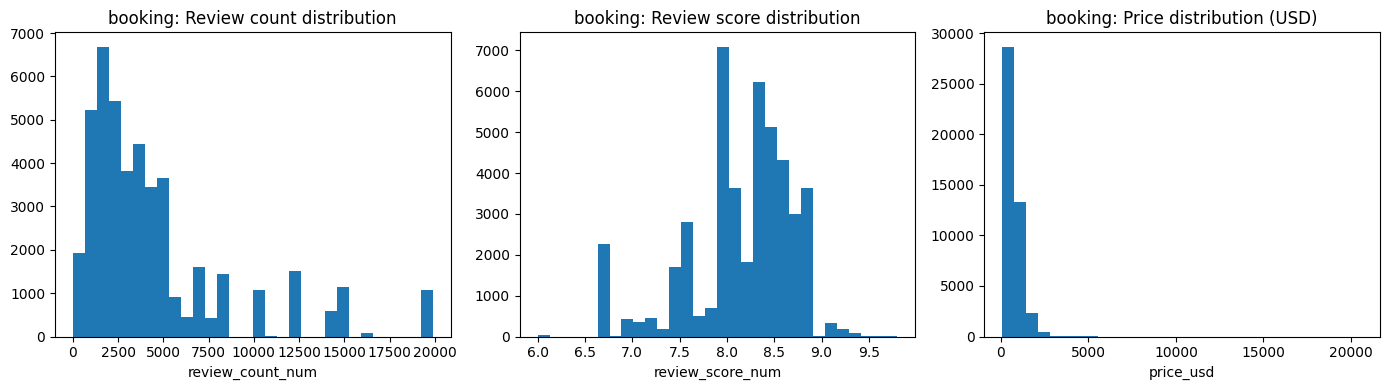

booking: rows before=45000, after outlier removal=43605
booking: distinct bed types: ['double', 'king', 'queen', 'single', 'twin']
BOOKING | PairGrid 


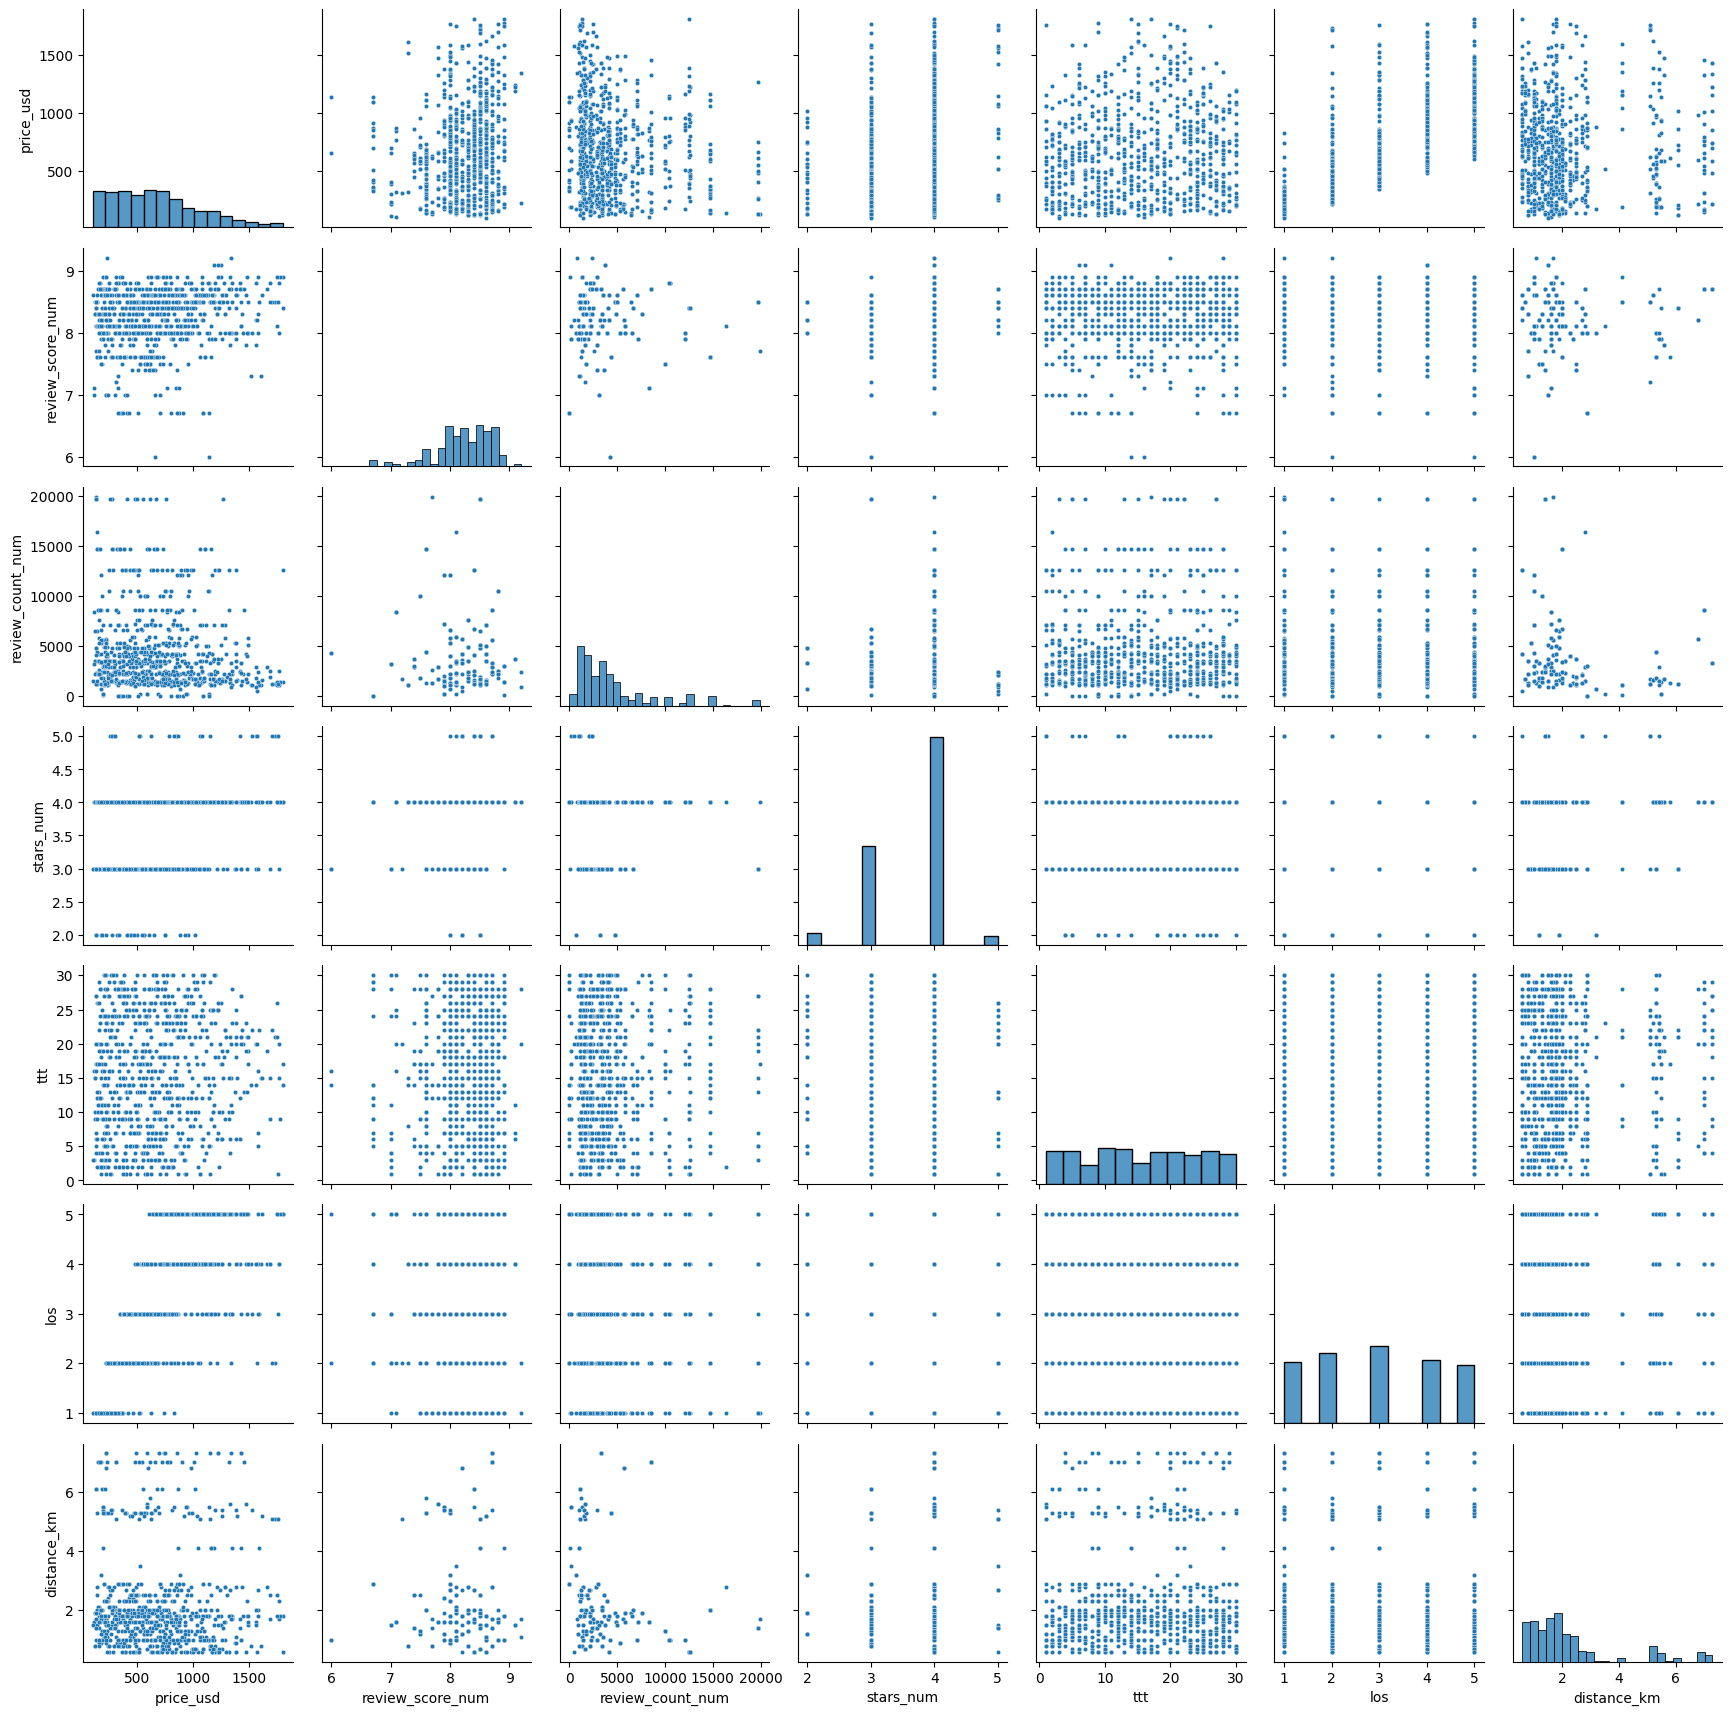

EXPEDIA | Distributions


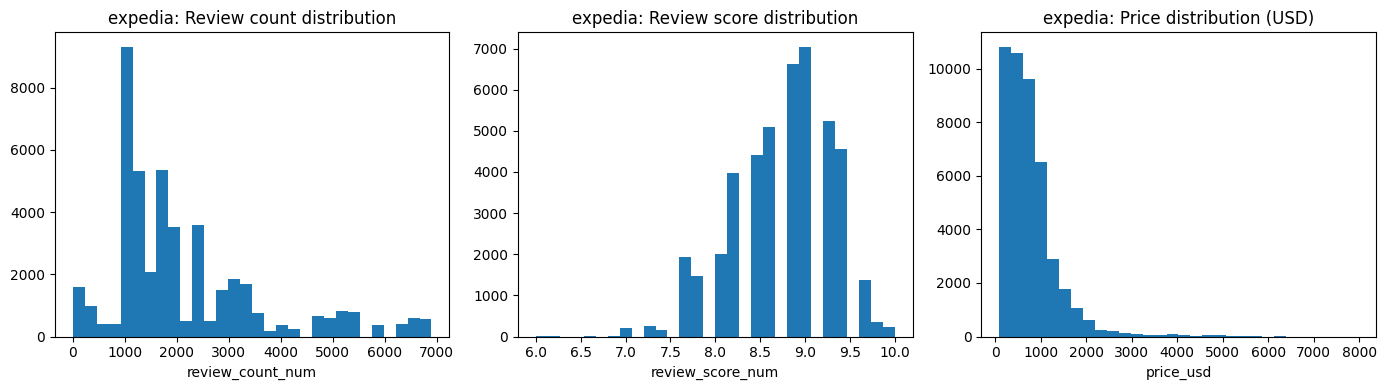

expedia: rows before=45000, after outlier removal=43011
expedia: distinct bed types: ['double', 'king', 'queen']
EXPEDIA | PairGrid 


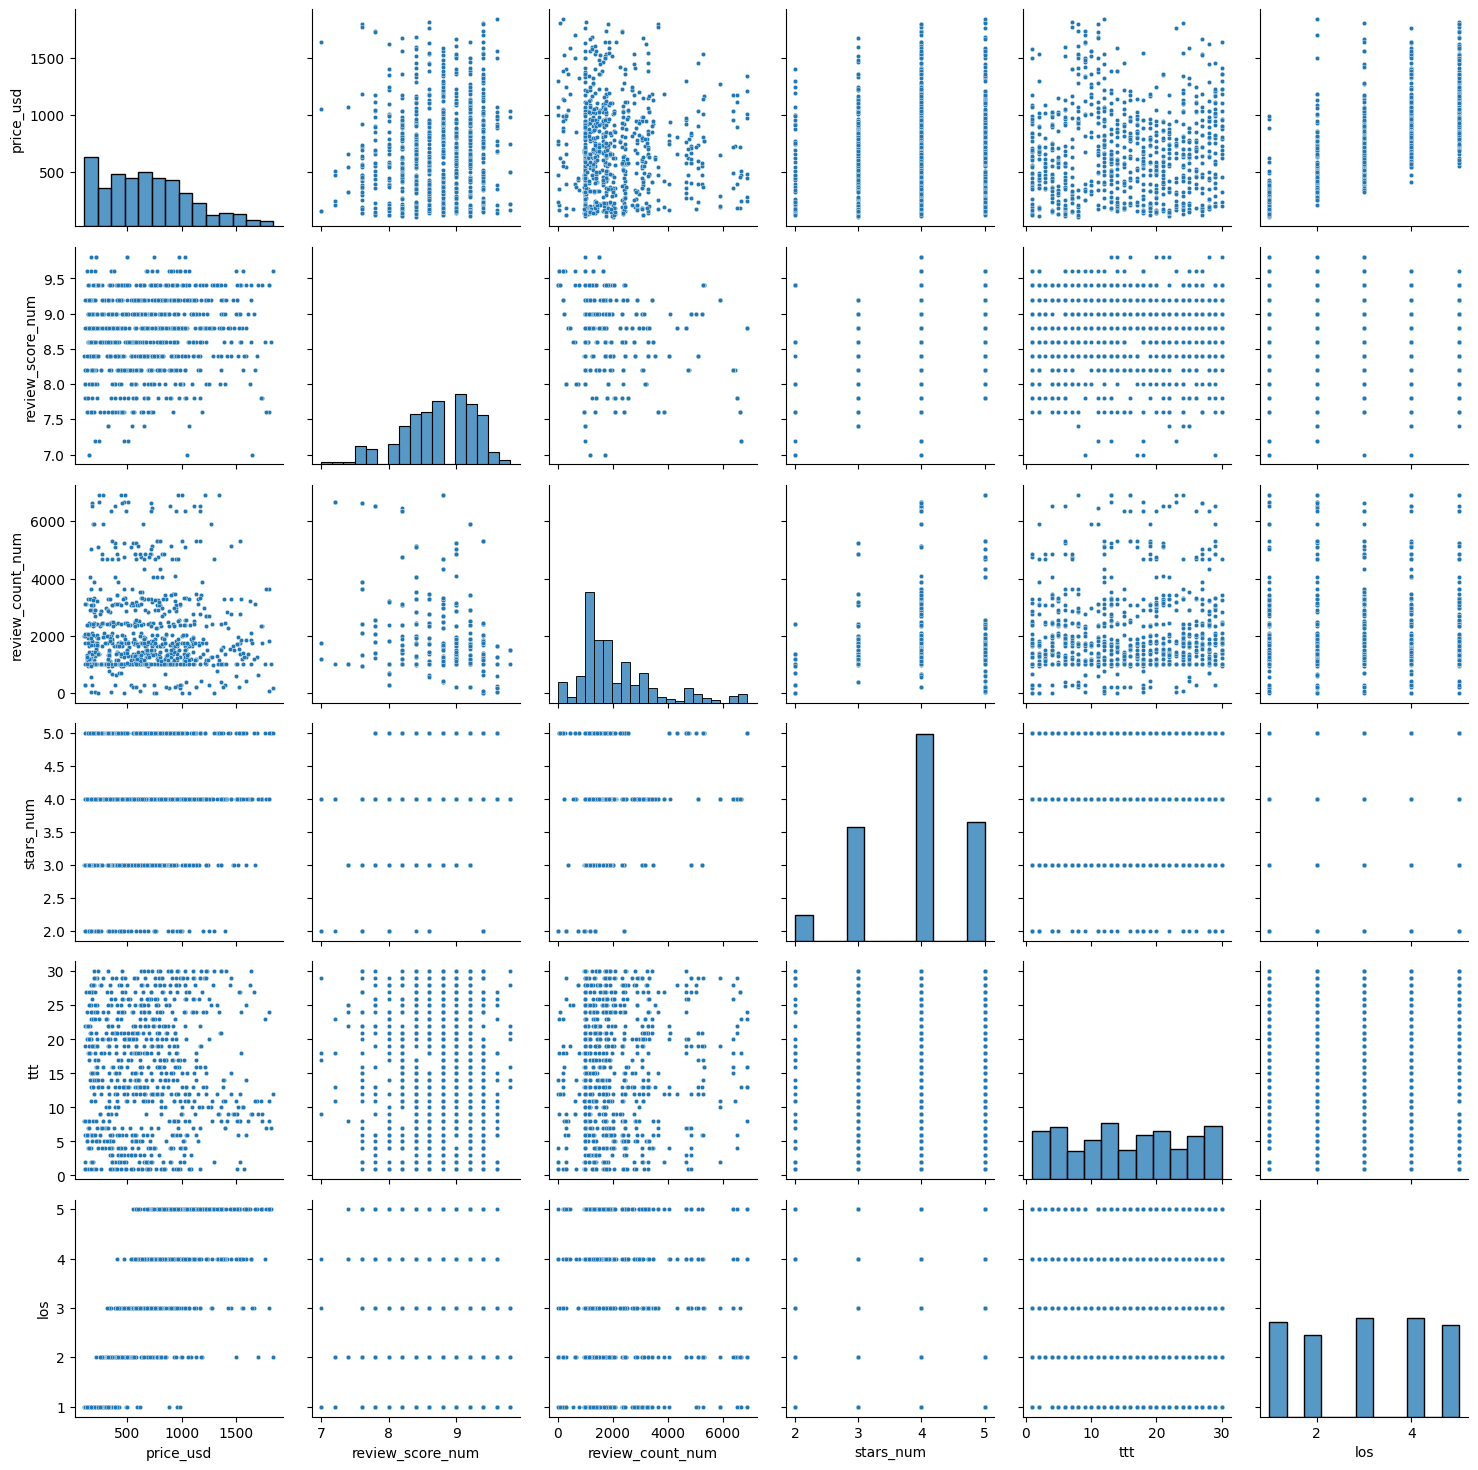

source
booking    45000
expedia    45000
Name: count, dtype: int64
COMBINED | Distributions


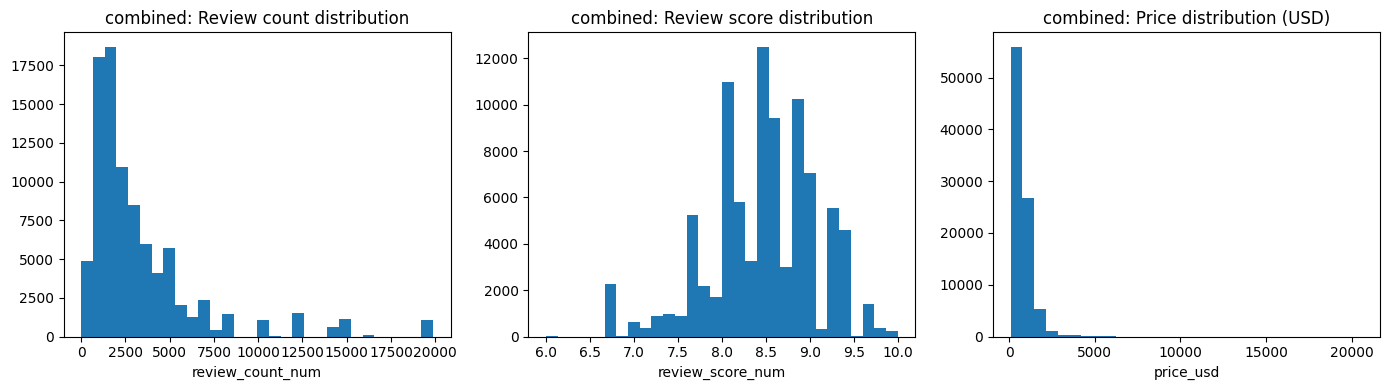

combined: rows before=90000, after outlier removal=86606
combined: distinct bed types: ['double', 'king', 'queen', 'single', 'twin']
COMBINED | PairGrid 


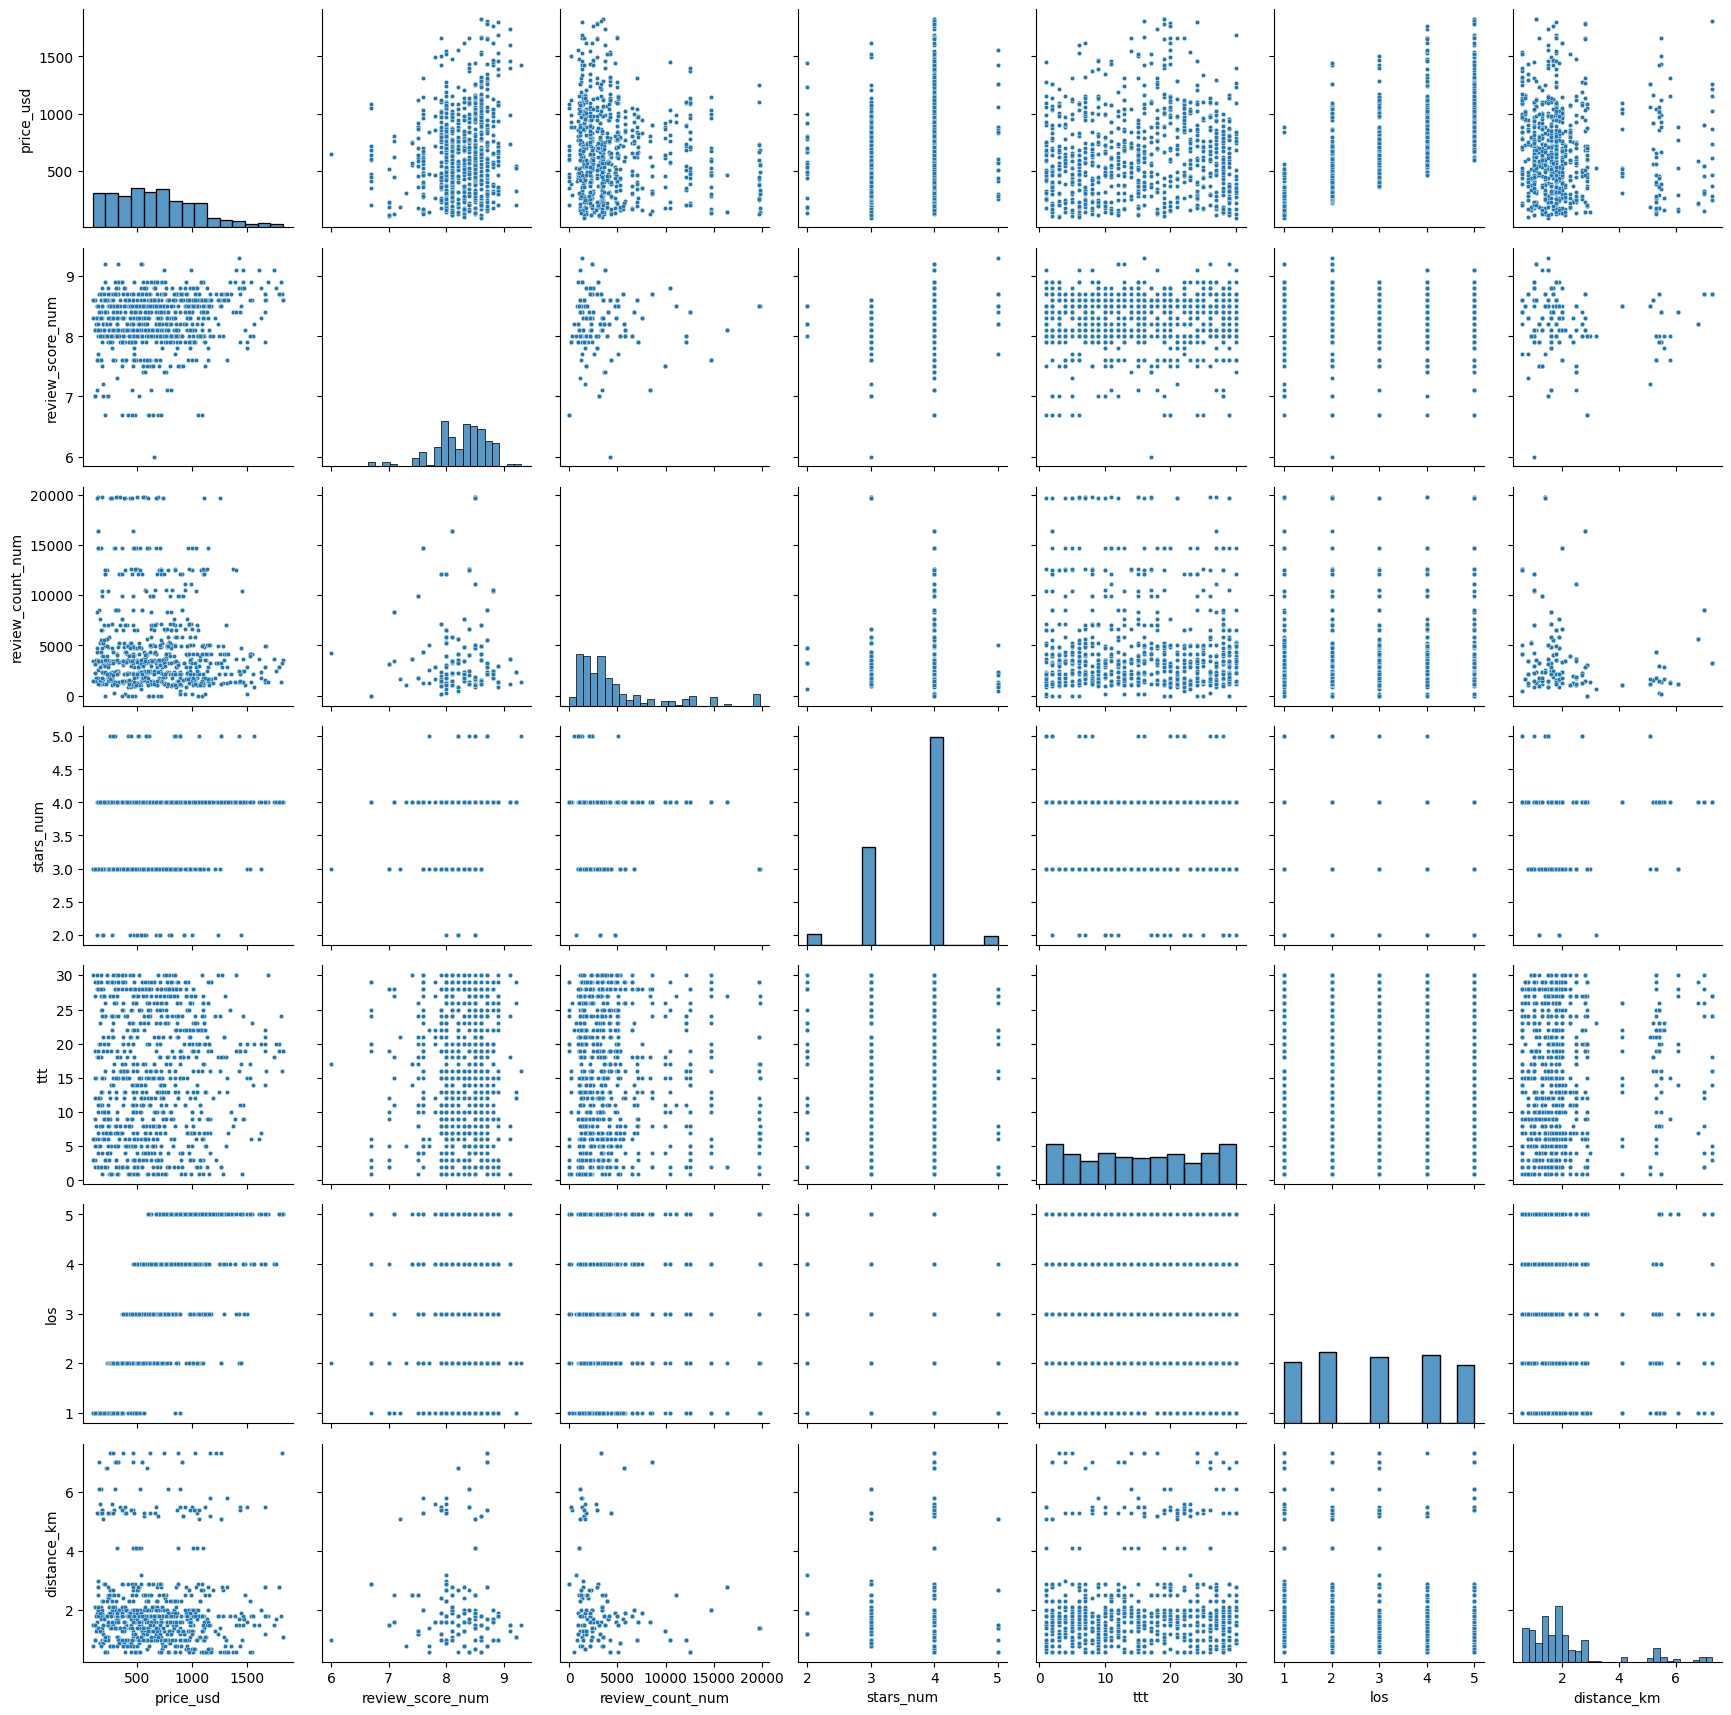

In [75]:
df_no_out_booking, feature_df_booking = run_stage_b_for(df_booking, "booking")
df_no_out_expedia, feature_df_expedia = run_stage_b_for(df_expedia, "expedia")

# combined
df_all = pd.concat([df_booking, df_expedia], ignore_index=True)
print(df_all["source"].value_counts())
df_no_out_all, feature_df_all = run_stage_b_for(df_all, "combined")


## Stage B — Distributions + Outlier

In this stage we explored basic distributions of key variables (review count, review score, and price) to understand scale, skewness/long tails, and the presence of extreme values.

### Booking
- Before outlier removal: **45,000** rows  
- After Tukey (1.5×IQR) filtering on `price_usd`: **43,605** rows  

### Expedia
- Before outlier removal: **45,000** rows  
- After Tukey (1.5×IQR) filtering on `price_usd`: **43,011** rows  

### Combined (Booking + Expedia)
- Before outlier removal: **90,000** rows  
- After Tukey filtering: **86,606** rows  

To make the dataset usable for ML models, we converted text-based fields into numerical representations.

### Ordinal features (meaningful order)
- `review_label` → `review_label_ord`: Text labels such as "Good / Very Good / Excellent" were mapped to numeric values preserving the natural order.
- `bed_type` → `bed_type_ord`: Bed types were mapped to numeric values using a domain-based ordering (e.g., King > Queen > Double ...).

**Observed bed-type categories**
- Booking: `['double', 'king', 'queen', 'single', 'twin']`
- Expedia: `['double', 'king', 'queen']`

### Nominal / categorical features 
- `cancellation_cat` (e.g., free/unknown/...) → One-Hot
- `neighborhood` (NYC neighborhood) → One-Hot

One-Hot encoding allows the model to learn a separate effect per category without imposing any artificial ordering.


-----------------------------------------------------------------------------------------------------------------

# Part A - Stage C: Price Prediction


Stage C Setup

We train regression models to predict price_usd using engineered features.
We train on the combined dataset (Booking + Expedia) and report:

overall test metrics

test metrics separately for Booking and Expedia.

In [21]:
import numpy as np
import pandas as pd

assert "feature_df_booking" in globals(), "feature_df_booking not found. Run Stage B first."
assert "feature_df_expedia" in globals(), "feature_df_expedia not found. Run Stage B first."
assert "feature_df_all" in globals(), "feature_df_all not found. Create df_all and run Stage B for combined."

TARGET_COL = "price_usd"

# Combined modeling df
df_model = feature_df_all.copy()
assert TARGET_COL in df_model.columns, "price_usd missing from feature_df_all"
assert "source" in df_model.columns, "source missing in feature_df_all (required for per-site metrics)"

# Drop missing target
df_model = df_model.dropna(subset=[TARGET_COL]).replace([np.inf, -np.inf], np.nan).copy()

source_all = df_model["source"].astype(str)

y = df_model[TARGET_COL].astype(float)
X = df_model.drop(columns=[TARGET_COL, "source"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sources:", source_all.value_counts().to_dict())


X shape: (86606, 21)
y shape: (86606,)
Sources: {'booking': 43703, 'expedia': 42903}


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Split once and reuse for all models
X_train, X_test, y_train, y_test, src_train, src_test = train_test_split(
    X, y, source_all, test_size=0.30, random_state=7, stratify=source_all
)

# Median imputation (keeps models stable)
imp = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imp.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train_imp.shape, "Test:", X_test_imp.shape)
print("Test sources:", src_test.value_counts().to_dict())


Train: (60624, 21) Test: (25982, 21)
Test sources: {'booking': 13111, 'expedia': 12871}


# Task 1: regression models
In this section we train and evaluate regressors

For each model we report: R², MAE, MSE, RMSE on both train and test, and we plot a residual plot on the test set.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
    }

def residual_plot(y_true, y_pred, title):
    resid = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, resid, s=7, alpha=0.35)
    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Predicted price (USD)")
    plt.ylabel("Residual (true - pred)")
    plt.tight_layout()
    plt.show()


In [24]:
def eval_train_test(model, X_train, y_train, X_test, y_test, model_name="model", plot_residuals=True):
    # Fit
    model.fit(X_train, y_train)

    # Predict
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    # Metrics
    train_m = compute_metrics(y_train, pred_train)
    test_m  = compute_metrics(y_test,  pred_test)

    row = {
        "model": model_name,
        **{f"train_{k}": v for k, v in train_m.items()},
        **{f"test_{k}":  v for k, v in test_m.items()},
    }

    if plot_residuals:
        residual_plot(y_test, pred_test, f"{model_name} — Residual Plot (Test)")

    return row, pred_train, pred_test

def eval_by_source(y_true, y_pred, src_series):
    """
    Always returns a standard table with:
    group: overall / booking / expedia
    test_R2, test_MAE, test_MSE, test_RMSE
    n
    """
    src_vals = pd.Series(src_series).reset_index(drop=True)
    y_true_s = pd.Series(y_true).reset_index(drop=True)
    y_pred_s = pd.Series(y_pred).reset_index(drop=True)

    def metrics_row(mask, label):
        m = compute_metrics(y_true_s[mask], y_pred_s[mask])
        return {
            "group": label,
            "test_R2": float(m["R2"]),
            "test_MAE": float(m["MAE"]),
            "test_MSE": float(m["MSE"]),
            "test_RMSE": float(m["RMSE"]),
            "n": int(mask.sum())
        }

    rows = []

    # overall
    mask_all = np.ones(len(src_vals), dtype=bool)
    rows.append(metrics_row(mask_all, "overall"))

    # per source
    for s in ["booking", "expedia"]:
        mask = (src_vals == s).to_numpy()
        if mask.sum() == 0:
            continue
        rows.append(metrics_row(mask, s))

    return pd.DataFrame(rows)




In [25]:
from dataclasses import dataclass
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

CANDIDATES = []  # list of dicts

def register_candidate(name, model, X_test, y_test, notes=""):
    """
    Save a fitted model + its matching test set and compute metrics.
    model must support .predict(X_test)
    X_test should preferably be a DataFrame (keeps index + columns)
    """
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))

    CANDIDATES.append({
        "name": name,
        "rmse_test": rmse,
        "r2_test": r2,
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "notes": notes,
    })

    print(f"Registered: {name} | RMSE={rmse:.4f} | R²={r2:.4f}")

def candidates_summary():
    df = pd.DataFrame([{
        "name": c["name"],
        "rmse_test": c["rmse_test"],
        "r2_test": c["r2_test"],
        "notes": c["notes"],
    } for c in CANDIDATES]).sort_values("rmse_test").reset_index(drop=True)
    return df

def pick_final_best():
    df = candidates_summary()
    assert len(df) > 0, "No candidates registered yet."
    winner_name = df.loc[0, "name"]
    winner = next(c for c in CANDIDATES if c["name"] == winner_name)
    print("FINAL BEST:", winner_name, "| RMSE:", winner["rmse_test"])
    return winner, df


# Three regression models ( taught in class)
In this section we train and evaluate three regressors:

LinearRegression

DecisionTreeRegressor

GaussianProcessRegressor

**LinearRegression**

LinearRegression:


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.656964,163.896478,52145.937161,228.354849,25982
1,booking,0.684506,149.428622,47599.608344,218.173345,13111
2,expedia,0.629192,178.634110,56777.039416,238.279331,12871


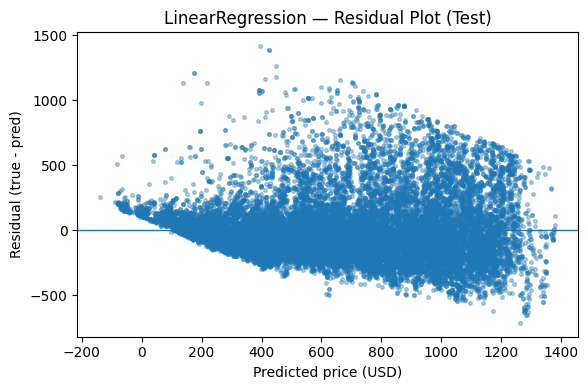

In [26]:
# LinearRegression

from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X_train_imp, y_train)

pred_lin = lin.predict(X_test_imp)
lin_table = eval_by_source(y_test.values, pred_lin, src_test)

print("LinearRegression:")
display(lin_table)
residual_plot(y_test.values, pred_lin, "LinearRegression — Residual Plot (Test)")


# DecisionTreeRegressor


DecisionTreeRegressor:


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.837099,99.551583,24763.053516,157.362809,25982
1,booking,0.873120,83.416344,19142.826628,138.357604,13111
2,expedia,0.800884,115.987689,30488.078358,174.608357,12871


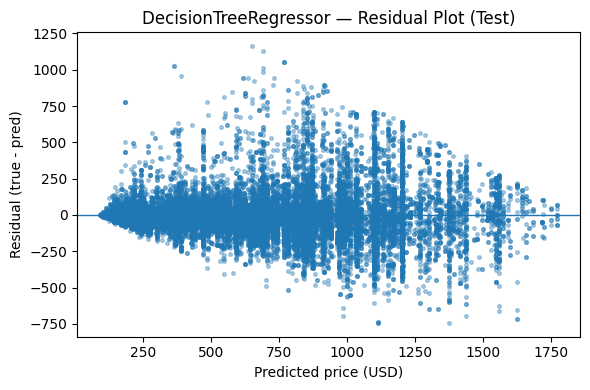

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=7, max_depth=12, min_samples_leaf=10)
dt.fit(X_train_imp, y_train)

pred_dt = dt.predict(X_test_imp)
dt_table = eval_by_source(y_test.values, pred_dt, src_test)

print("DecisionTreeRegressor:")
display(dt_table)
residual_plot(y_test.values, pred_dt, "DecisionTreeRegressor — Residual Plot (Test)")


# GaussianProcessRegressor

GaussianProcessRegressor:


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.469530,206.328146,80638.268640,283.968781,25982
1,booking,0.554924,183.730333,67149.952268,259.133078,13111
2,expedia,0.383622,229.347331,94378.095845,307.210182,12871


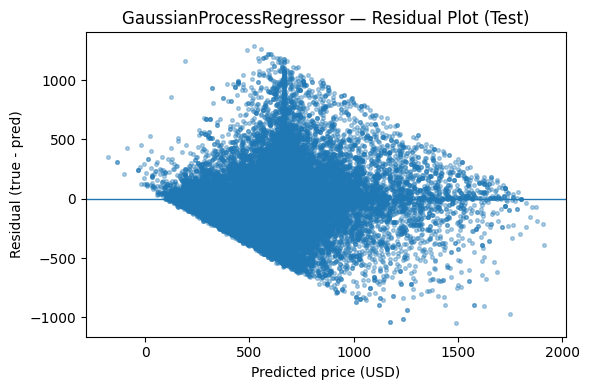

In [28]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

GPR_TRAIN_SAMPLES = 2000  # adjust 1000–3000
rs = np.random.RandomState(7)

if len(X_train_imp) > GPR_TRAIN_SAMPLES:
    idx = rs.choice(len(X_train_imp), size=GPR_TRAIN_SAMPLES, replace=False)
    X_train_gpr = X_train_imp.iloc[idx]
    y_train_gpr = y_train.iloc[idx]
else:
    X_train_gpr = X_train_imp
    y_train_gpr = y_train

kernel = C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, random_state=7, normalize_y=True)

gpr.fit(X_train_gpr, y_train_gpr)

pred_gpr = gpr.predict(X_test_imp)
gpr_table = eval_by_source(y_test.values, pred_gpr, src_test)

print("GaussianProcessRegressor:")
display(gpr_table)
residual_plot(y_test.values, pred_gpr, "GaussianProcessRegressor — Residual Plot (Test)")


# Three additional regression models (not taught in class)
In this section we train and evaluate three regressors:

RandomForestRegressor

GradientBoostingRegressor

SVR (SVM regression) with feature scaling


# RandomForestRegressor

Random Forest is an ensemble of decision trees.
It usually performs well on tabular data without requiring feature scaling.

RandomForestRegressor:


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.960586,39.706324,5991.452280,77.404472,25982
1,booking,0.986710,22.166649,2005.145758,44.778854,13111
2,expedia,0.934350,57.573055,10052.089744,100.260110,12871


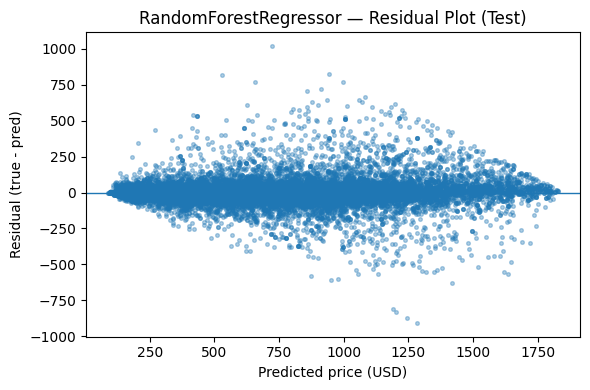

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=7,
    n_jobs=-1
)

rf.fit(X_train_imp, y_train)

pred_rf = rf.predict(X_test_imp)
rf_table = eval_by_source(y_test.values, pred_rf, src_test)

print("RandomForestRegressor:")
display(rf_table)
residual_plot(y_test.values, pred_rf, "RandomForestRegressor — Residual Plot (Test)")


# GradientBoostingRegressor

Gradient Boosting builds trees sequentially, where each tree corrects the errors of the previous ones.
It often achieves strong performance on structured/tabular datasets.

GradientBoostingRegressor:


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.814643,116.268686,28176.706632,167.859187,25982
1,booking,0.825649,109.446805,26304.880571,162.187794,13111
2,expedia,0.803527,123.217773,30083.435828,173.445772,12871


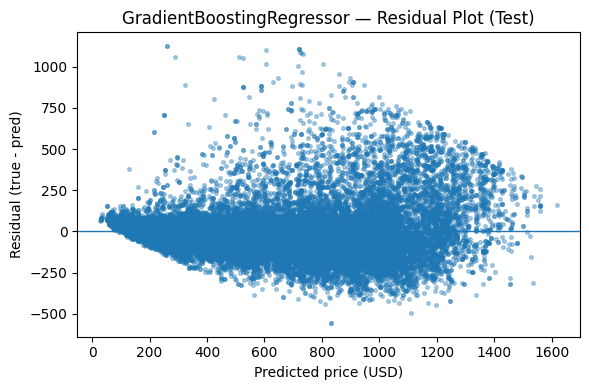

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=7
)

gbr.fit(X_train_imp, y_train)

pred_gbr = gbr.predict(X_test_imp)
gbr_table = eval_by_source(y_test.values, pred_gbr, src_test)

print("GradientBoostingRegressor:")
display(gbr_table)
residual_plot(y_test.values, pred_gbr, "GradientBoostingRegressor — Residual Plot (Test)")



# SVR (Support Vector Regression)

SVR is sensitive to feature scales, so we use StandardScaler in a pipeline.
SVR can be slow on large datasets, so we optionally subsample the training set for speed.

SVR (RBF):


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.687946,135.833555,47436.324654,217.798817,25982
1,booking,0.730693,121.146945,40631.174883,201.571761,13111
2,expedia,0.644923,150.794019,54368.367125,233.170254,12871


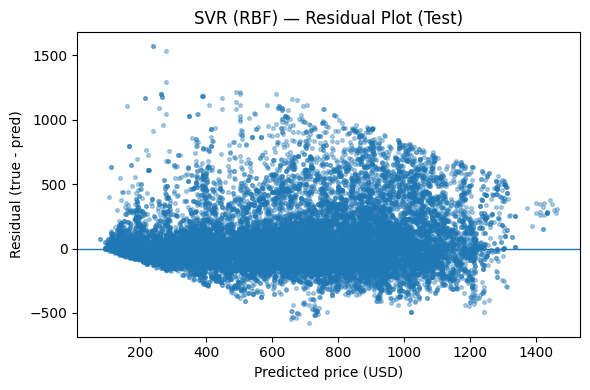

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SVR_TRAIN_MAX = 12000  # try 4000-12000 depending on your machine
rs = np.random.RandomState(7)

if len(X_train_imp) > SVR_TRAIN_MAX:
    idx = rs.choice(len(X_train_imp), size=SVR_TRAIN_MAX, replace=False)
    X_train_svr = X_train_imp.iloc[idx]
    y_train_svr = y_train.iloc[idx]
else:
    X_train_svr = X_train_imp
    y_train_svr = y_train
# Scale features (critical for SVR)
scaler = StandardScaler()
X_train_svr_sc = scaler.fit_transform(X_train_svr)
X_test_sc = scaler.transform(X_test_imp)

svr = SVR(kernel="rbf", C=30.0, gamma="scale", epsilon=0.1)
svr.fit(X_train_svr_sc, y_train_svr)

pred_svr = svr.predict(X_test_sc)
svr_table = eval_by_source(y_test.values, pred_svr, src_test)

print("SVR (RBF):")
display(svr_table)
residual_plot(y_test.values, pred_svr, "SVR (RBF) — Residual Plot (Test)")

In [32]:
def overall_row(model_name, by_source_table):
    """
    Expects eval_by_source() output
    """
    t = by_source_table.copy()
    required = ["group", "test_R2", "test_MAE", "test_MSE", "test_RMSE", "n"]
    missing = [c for c in required if c not in t.columns]
    assert not missing, f"Missing columns in by_source_table: {missing}"

    overall = t.loc[t["group"] == "overall"]
    assert len(overall) == 1, "Expected exactly one 'overall' row"
    row0 = overall.iloc[0]

    return pd.DataFrame([{
        "model": model_name,
        "R2": row0["test_R2"],
        "MAE": row0["test_MAE"],
        "MSE": row0["test_MSE"],
        "RMSE": row0["test_RMSE"],
        "n": int(row0["n"])
    }])


summary = pd.concat([
    overall_row("LinearRegression", lin_table),
    overall_row("DecisionTree", dt_table),
    overall_row("GaussianProcess", gpr_table),
    overall_row("RandomForest", rf_table),
    overall_row("GradientBoosting", gbr_table),
    overall_row("SVR (RBF)", svr_table),
], ignore_index=True)

display(summary)


,model,R2,MAE,MSE,RMSE,n
0,LinearRegression,0.656964,163.896478,52145.937161,228.354849,25982
1,DecisionTree,0.837099,99.551583,24763.053516,157.362809,25982
2,GaussianProcess,0.469530,206.328146,80638.268640,283.968781,25982
3,RandomForest,0.960586,39.706324,5991.452280,77.404472,25982
4,GradientBoosting,0.814643,116.268686,28176.706632,167.859187,25982
5,SVR (RBF),0.687946,135.833555,47436.324654,217.798817,25982


# Task 2

In this task we experiment with different hyperparameters for our models and compare performance on the test set.
We report R², MAE, MSE, RMSE and select the best configuration per model.

In [33]:
import numpy as np
import pandas as pd

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
    }

def run_experiments_with_best_by_source(model_name, configs, build_model_fn,
                                       X_train, y_train, X_test, y_test, src_test):
    rows = []
    best_cfg = None
    best_model = None
    best_pred = None
    best_rmse = float("inf")

    for cfg in configs:
        model = build_model_fn(cfg)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        overall = compute_metrics(y_test.values, pred)
        row = {"model": model_name, **cfg, **{f"test_{k}": v for k, v in overall.items()}}
        rows.append(row)

        if overall["RMSE"] < best_rmse:
            best_rmse = overall["RMSE"]
            best_cfg = cfg
            best_model = model
            best_pred = pred

    results_df = pd.DataFrame(rows).sort_values("test_RMSE").reset_index(drop=True)
    best_table = eval_by_source(y_test.values, best_pred, src_test)

    return results_df, best_cfg, best_table, best_model


# LinearRegression hyperparameters

We vary fit_intercept and positive (for positive price predictions).

In [34]:
from sklearn.linear_model import LinearRegression

lr_configs = [
    {"fit_intercept": True,  "positive": False},
    {"fit_intercept": True,  "positive": True},
    {"fit_intercept": False, "positive": False},
]

def build_lr(cfg):
    return LinearRegression(fit_intercept=cfg["fit_intercept"], positive=cfg["positive"])

lr_results, lr_best_cfg, lr_best_by_source, lr_best_model = run_experiments_with_best_by_source(
    "LinearRegression",
    lr_configs,
    build_lr,
    X_train_imp, y_train,
    X_test_imp,  y_test,
    src_test
)

display(lr_results)
print("Best LinearRegression config:", lr_best_cfg)
display(lr_best_by_source)


,model,fit_intercept,positive,test_R2,test_MAE,test_MSE,test_RMSE
0,LinearRegression,True,False,0.656964,163.896478,52145.937161,228.354849
1,LinearRegression,False,False,0.656964,163.896478,52145.937161,228.354849
2,LinearRegression,True,True,0.653511,164.448681,52670.764894,229.501122


Best LinearRegression config: {'fit_intercept': True, 'positive': False}


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.656964,163.896478,52145.937161,228.354849,25982
1,booking,0.684506,149.428622,47599.608344,218.173345,13111
2,expedia,0.629192,178.634110,56777.039416,238.279331,12871


# DecisionTreeRegressor hyperparameters

We vary max_depth, min_samples_leaf, min_samples_split.

In [35]:
from sklearn.tree import DecisionTreeRegressor

dt_configs = [
    {"max_depth": 10,  "min_samples_leaf": 20, "min_samples_split": 10},
    {"max_depth": 15,  "min_samples_leaf": 10, "min_samples_split": 5},
    {"max_depth": 20,  "min_samples_leaf": 5,  "min_samples_split": 2},
    {"max_depth": None,"min_samples_leaf": 5,  "min_samples_split": 2},
]

def build_dt(cfg):
    return DecisionTreeRegressor(
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        min_samples_split=cfg["min_samples_split"],
        random_state=7
    )

dt_results, dt_best_cfg, dt_best_by_source, dt_best_model = run_experiments_with_best_by_source(
    "DecisionTreeRegressor",
    dt_configs,
    build_dt,
    X_train_imp, y_train,
    X_test_imp,  y_test,
    src_test
)

display(dt_results)
print("Best DecisionTree config:", dt_best_cfg)
display(dt_best_by_source)


,model,max_depth,min_samples_leaf,min_samples_split,test_R2,test_MAE,test_MSE,test_RMSE
0,DecisionTreeRegressor,NaN,5,2,0.929326,54.963254,10743.313086,103.649955
1,DecisionTreeRegressor,20.0,5,2,0.926546,57.305294,11166.012353,105.669354
2,DecisionTreeRegressor,15.0,10,5,0.881728,80.761510,17978.884581,134.085363
3,DecisionTreeRegressor,10.0,20,10,0.789813,117.322045,31951.187906,178.748952


Best DecisionTree config: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.929326,54.963254,10743.313086,103.649955,25982
1,booking,0.959893,39.681223,6051.008734,77.788230,13111
2,expedia,0.898619,70.530241,15523.112818,124.591785,12871


# GaussianProcessRegressor hyperparameters

We vary n_restarts_optimizer and alpha (noise). Use subsampled train set for speed.

In [36]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
import numpy as np

GPR_TRAIN_MAX = 4000  # try 1000–3000 depending on your machine
rs = np.random.RandomState(7)

if len(X_train_imp) > GPR_TRAIN_MAX:
    idx = rs.choice(len(X_train_imp), size=GPR_TRAIN_MAX, replace=False)
    X_train_gpr = X_train_imp.iloc[idx]
    y_train_gpr = y_train.iloc[idx]
else:
    X_train_gpr = X_train_imp
    y_train_gpr = y_train

print("GPR train size:", X_train_gpr.shape)


gpr_configs = [
    {"kernel": ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0), "alpha": 1e-6},
    {"kernel": ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0), "alpha": 1e-6},
    {"kernel": ConstantKernel(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0) + WhiteKernel(noise_level=1.0), "alpha": 1e-6},
]

def build_gpr(cfg):
    return GaussianProcessRegressor(
        kernel=cfg["kernel"],
        alpha=cfg["alpha"],
        normalize_y=True,
        random_state=7
    )

gpr_results, gpr_best_cfg, gpr_best_by_source, gpr_best_model = run_experiments_with_best_by_source(
    "GaussianProcessRegressor",
    gpr_configs,
    build_gpr,
    X_train_gpr, y_train_gpr,
    X_test_imp,  y_test,
    src_test
)

display(gpr_results)
print("Best GPR config:", gpr_best_cfg)
display(gpr_best_by_source)


GPR train size: (4000, 21)


,model,kernel,alpha,test_R2,test_MAE,test_MSE,test_RMSE
0,GaussianProcessRegressor,"1**2 * Matern(length_scale=1, nu=1.5) + WhiteK...",0.000001,0.811668,110.011364,28628.977034,169.200996
1,GaussianProcessRegressor,"1**2 * RationalQuadratic(alpha=1, length_scale...",0.000001,0.801405,106.562193,30188.984154,173.749775
2,GaussianProcessRegressor,1**2 * RBF(length_scale=1) + WhiteKernel(noise...,0.000001,0.728121,130.411349,41329.215302,203.295881


Best GPR config: {'kernel': 1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1), 'alpha': 1e-06}


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.811668,110.011364,28628.977034,169.200996,25982
1,booking,0.829033,98.863324,25794.283009,160.605987,13111
2,expedia,0.794167,121.367276,31516.528378,177.528951,12871


# RandomForest hyperparameters

We vary key RandomForest parameters:

n_estimators (number of trees)

max_depth (tree depth)

min_samples_leaf (leaf size)

max_features (feature sampling per split)

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_configs = [
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 600, "max_depth": 20,   "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 600, "max_depth": 20,   "min_samples_leaf": 5, "max_features": "sqrt"},
    {"n_estimators": 800, "max_depth": 15,   "min_samples_leaf": 5, "max_features": "sqrt"},
]

def build_rf(cfg):
    return RandomForestRegressor(
        random_state=7,
        n_jobs=-1,
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
    )

rf_results, rf_best_cfg, rf_best_by_source, rf_best_model = run_experiments_with_best_by_source(
    "RandomForestRegressor",
    rf_configs,
    build_rf,
    X_train_imp, y_train,
    X_test_imp,  y_test,
    src_test
)

display(rf_results)
print("Best RandomForest config:", rf_best_cfg)
display(rf_best_by_source)


,model,n_estimators,max_depth,min_samples_leaf,max_features,test_R2,test_MAE,test_MSE,test_RMSE
0,RandomForestRegressor,600,NaN,1,sqrt,0.966254,33.705244,5129.812785,71.622711
1,RandomForestRegressor,300,NaN,1,sqrt,0.966209,33.760354,5136.600036,71.670078
2,RandomForestRegressor,600,20.0,1,sqrt,0.959846,42.631857,6103.916771,78.127567
3,RandomForestRegressor,600,20.0,5,sqrt,0.915259,72.694087,12881.721737,113.497673
4,RandomForestRegressor,800,15.0,5,sqrt,0.878107,90.877041,18529.249088,136.122184


Best RandomForest config: {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.966254,33.705244,5129.812785,71.622711,25982
1,booking,0.995189,10.920316,725.812798,26.940913,13111
2,expedia,0.937199,56.915033,9615.932266,98.060860,12871


# GradientBoosting hyperparameters

We experiment with:

n_estimators

learning_rate

max_depth

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_configs = [
    {"n_estimators": 200, "learning_rate": 0.10, "max_depth": 3, "subsample": 1.0},
    {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 3, "subsample": 1.0},
    {"n_estimators": 800, "learning_rate": 0.03, "max_depth": 3, "subsample": 1.0},
    {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 2, "subsample": 1.0},
    {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.8},
]

def build_gbr(cfg):
    return GradientBoostingRegressor(
        random_state=7,
        n_estimators=cfg["n_estimators"],
        learning_rate=cfg["learning_rate"],
        max_depth=cfg["max_depth"],
        subsample=cfg["subsample"],
    )

gbr_results, gbr_best_cfg, gbr_best_by_source, gbr_best_model = run_experiments_with_best_by_source(
    "GradientBoostingRegressor",
    gbr_configs,
    build_gbr,
    X_train_imp, y_train,
    X_test_imp,  y_test,
    src_test
)

display(gbr_results)
print("Best GradientBoosting config:", gbr_best_cfg)
display(gbr_best_by_source)


,model,n_estimators,learning_rate,max_depth,subsample,test_R2,test_MAE,test_MSE,test_RMSE
0,GradientBoostingRegressor,800,0.03,3,1.0,0.823108,113.069642,26889.883171,163.981350
1,GradientBoostingRegressor,400,0.05,3,0.8,0.817339,115.079140,27766.849219,166.633878
2,GradientBoostingRegressor,400,0.05,3,1.0,0.814643,116.268686,28176.706632,167.859187
3,GradientBoostingRegressor,200,0.10,3,1.0,0.813395,116.466970,28366.316557,168.423029
4,GradientBoostingRegressor,400,0.05,2,1.0,0.749078,137.331760,38143.371576,195.303281


Best GradientBoosting config: {'n_estimators': 800, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 1.0}


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.823108,113.069642,26889.883171,163.981350,25982
1,booking,0.832478,107.125019,25274.516222,158.979609,13111
2,expedia,0.813637,119.125112,28535.371173,168.924158,12871


# SVR hyperparameters

SVR is sensitive to scaling and can be slow.
We vary:

C

epsilon

(kernel fixed to RBF)

In [39]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Optional: speed guard (SVR can be slow)
SVR_TRAIN_MAX = 8000
rs = np.random.RandomState(7)
if len(X_train_imp) > SVR_TRAIN_MAX:
    idx = rs.choice(len(X_train_imp), size=SVR_TRAIN_MAX, replace=False)
    X_train_svr = X_train_imp.iloc[idx]
    y_train_svr = y_train.iloc[idx]
else:
    X_train_svr = X_train_imp
    y_train_svr = y_train

# Scale (fit on train, apply to train+test)
scaler = StandardScaler()
X_train_svr_sc = scaler.fit_transform(X_train_svr)
X_test_sc = scaler.transform(X_test_imp)

svr_configs = [
    {"C": 10.0, "epsilon": 0.1, "gamma": "scale"},
    {"C": 30.0, "epsilon": 0.1, "gamma": "scale"},
    {"C": 50.0, "epsilon": 0.1, "gamma": "scale"},
    {"C": 30.0, "epsilon": 0.2, "gamma": "scale"},
    {"C": 30.0, "epsilon": 0.1, "gamma": 0.05},
]

def build_svr(cfg):
    return SVR(kernel="rbf", C=cfg["C"], epsilon=cfg["epsilon"], gamma=cfg["gamma"])

# For SVR we call the same tuning helper, but we pass the scaled matrices
svr_results, svr_best_cfg, svr_best_by_source, svr_best_model = run_experiments_with_best_by_source(
    "SVR_RBF",
    svr_configs,
    build_svr,
    X_train_svr_sc, y_train_svr,   # scaled train
    X_test_sc,      y_test,        # scaled test
    src_test
)

display(svr_results)
print("Best SVR config:", svr_best_cfg)
display(svr_best_by_source)


,model,C,epsilon,gamma,test_R2,test_MAE,test_MSE,test_RMSE
0,SVR_RBF,50.0,0.1,scale,0.691013,134.989456,46970.117274,216.725904
1,SVR_RBF,30.0,0.1,0.05,0.672014,139.861717,49858.134541,223.289352
2,SVR_RBF,30.0,0.1,scale,0.671275,140.158019,49970.536813,223.540906
3,SVR_RBF,30.0,0.2,scale,0.671265,140.160274,49972.036101,223.544260
4,SVR_RBF,10.0,0.1,scale,0.623829,152.915855,57182.931090,239.129528


Best SVR config: {'C': 50.0, 'epsilon': 0.1, 'gamma': 'scale'}


,group,test_R2,test_MAE,test_MSE,test_RMSE,n
0,overall,0.691013,134.989456,46970.117274,216.725904,25982
1,booking,0.733906,120.731587,40146.447350,200.365784,13111
2,expedia,0.647845,149.513184,53921.025236,232.209012,12871


pick the best configuration

In [40]:
def best_row(model_name, best_cfg, best_by_source_table):
    """
    Takes the output of eval_by_source() (which contains a row 'overall')
    and returns a single-row summary with consistent column names.
    """
    t = best_by_source_table.copy()
    overall = t.loc[t["group"] == "overall"].iloc[0]

    return pd.DataFrame([{
        "model": model_name,
        "best_cfg": best_cfg,
        "R2": overall["test_R2"],
        "MAE": overall["test_MAE"],
        "MSE": overall["test_MSE"],
        "RMSE": overall["test_RMSE"],
        "n": int(overall["n"])
    }])


best_configs_summary = pd.concat([
    best_row("LinearRegression", lr_best_cfg, lr_best_by_source),
    best_row("DecisionTreeRegressor", dt_best_cfg, dt_best_by_source),
    best_row("GaussianProcessRegressor", gpr_best_cfg, gpr_best_by_source),
    best_row("RandomForestRegressor", rf_best_cfg, rf_best_by_source),
    best_row("GradientBoostingRegressor", gbr_best_cfg, gbr_best_by_source),
    best_row("SVR_RBF", svr_best_cfg, svr_best_by_source),
], ignore_index=True).sort_values("RMSE")

display(best_configs_summary)


,model,best_cfg,R2,MAE,MSE,RMSE,n
3,RandomForestRegressor,"{'n_estimators': 600, 'max_depth': None, 'min_...",0.966254,33.705244,5129.812785,71.622711,25982
1,DecisionTreeRegressor,"{'max_depth': None, 'min_samples_leaf': 5, 'mi...",0.929326,54.963254,10743.313086,103.649955,25982
4,GradientBoostingRegressor,"{'n_estimators': 800, 'learning_rate': 0.03, '...",0.823108,113.069642,26889.883171,163.981350,25982
2,GaussianProcessRegressor,"{'kernel': 1**2 * Matern(length_scale=1, nu=1....",0.811668,110.011364,28628.977034,169.200996,25982
5,SVR_RBF,"{'C': 50.0, 'epsilon': 0.1, 'gamma': 'scale'}",0.691013,134.989456,46970.117274,216.725904,25982
0,LinearRegression,"{'fit_intercept': True, 'positive': False}",0.656964,163.896478,52145.937161,228.354849,25982


In [41]:

best_configs_summary = best_configs_summary.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

best_models_by_name = {
    "LinearRegression": lr_best_model,
    "DecisionTreeRegressor": dt_best_model,
    "GaussianProcessRegressor": gpr_best_model,
    "RandomForestRegressor": rf_best_model,
    "GradientBoostingRegressor": gbr_best_model,
    "SVR": svr_best_model,
}

best_model_overall_row = best_configs_summary.iloc[0].to_dict()

best_model_overall_name = best_model_overall_row.get("model") or best_model_overall_row.get("name") or best_model_overall_row.get("model_name")
if best_model_overall_name is None:
    raise KeyError("Couldn't find model name column in best_configs_summary. Expected one of: 'model', 'name', 'model_name'.")

best_model_overall = best_models_by_name.get(best_model_overall_name)
if best_model_overall is None:
    raise KeyError(f"Winner model '{best_model_overall_name}' not found in best_models_by_name. "
                   f"Check the keys or your model naming in best_configs_summary.")

print("Overall best model:", best_model_overall_name)
print("Best row:", best_model_overall_row)


Overall best model: RandomForestRegressor
Best row: {'model': 'RandomForestRegressor', 'best_cfg': {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}, 'R2': 0.9662541198562452, 'MAE': 33.70524409782457, 'MSE': 5129.812785470626, 'RMSE': 71.62271138033401, 'n': 25982}


In [42]:
X_test_t2 = X_test_imp 
y_test_t2 = y_test

register_candidate("LinearRegression (Task2)", lr_best_model, X_test_t2, y_test_t2)
register_candidate("DecisionTreeRegressor (Task2)", dt_best_model, X_test_t2, y_test_t2)
register_candidate("GaussianProcessRegressor (Task2)", gpr_best_model, X_test_t2, y_test_t2)
register_candidate("RandomForestRegressor (Task2)", rf_best_model, X_test_t2, y_test_t2)
register_candidate("GradientBoostingRegressor (Task2)", gbr_best_model, X_test_t2, y_test_t2)
register_candidate("SVR_RBF (Task2)", svr_best_model, X_test_t2, y_test_t2)

display(candidates_summary())


Registered: LinearRegression (Task2) | RMSE=228.3548 | R²=0.6570
Registered: DecisionTreeRegressor (Task2) | RMSE=103.6500 | R²=0.9293
Registered: GaussianProcessRegressor (Task2) | RMSE=169.2010 | R²=0.8117
Registered: RandomForestRegressor (Task2) | RMSE=71.6227 | R²=0.9663
Registered: GradientBoostingRegressor (Task2) | RMSE=163.9814 | R²=0.8231


C:\Users\Roni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


Registered: SVR_RBF (Task2) | RMSE=396.3298 | R²=-0.0333


,name,rmse_test,r2_test,notes
0,RandomForestRegressor (Task2),71.622711,0.966254,
1,DecisionTreeRegressor (Task2),103.649955,0.929326,
2,GradientBoostingRegressor (Task2),163.981350,0.823108,
3,GaussianProcessRegressor (Task2),169.200996,0.811668,
4,LinearRegression (Task2),228.354849,0.656964,
5,SVR_RBF (Task2),396.329838,-0.033315,


## Baseline Regression Results

We evaluated several regression models as baselines to determine whether hotel price behaves mostly linearly or requires non-linear modeling.

### Overall (Test)
- **LinearRegression:** R² = **0.656964**, MAE = **163.896**, RMSE = **228.355**
- **DecisionTreeRegressor:** R² = **0.837099**, MAE = **99.552**, RMSE = **157.363**
- **GaussianProcessRegressor:** R² = **0.469530**, MAE = **206.328**, RMSE = **283.969**
- **RandomForestRegressor:** R² = **0.960586**, MAE = **39.706**, RMSE = **77.404**
- **GradientBoostingRegressor:** R² = **0.814643**, MAE = **116.269**, RMSE = **167.859**
- **SVR (RBF):** R² = **0.687946**, MAE = **135.834**, RMSE = **217.799**

**Key takeaway:** Tree ensembles clearly dominate. The jump from LinearRegression (R²≈0.657) to RandomForest (R²≈0.961) indicates strong non-linear relationships and feature interactions in pricing.

### Per-source performance (Test)
RandomForest performs very differently across sources:
- **Booking:** R² = **0.986710**, RMSE = **44.779**, MAE = **22.167**
- **Expedia:** R² = **0.934350**, RMSE = **100.260**, MAE = **57.573**

This suggests Expedia is harder to predict from the available card features (less consistent/less informative fields, different price presentation, or higher noise).

# Task 3

In this task we create additional engineered features that may improve price prediction.
We then rebuild the modeling table and compare model performance before vs. after feature engineering.

### Engineered features implemented

We add the following features derived from existing columns:
- `checkin_dow` (day of week of check-in, 0=Mon..6=Sun)
- `is_weekend_checkin` (Fri/Sat/Sun)
- `is_month_end_checkin` (check-in within last 3 days of the month)
- `is_month_start_checkin` (check-in within first 3 days of the month)
- `los_log` and `ttt_log` (log transforms to reduce skew)
- `ttt_x_los` (interaction term)


In [43]:
import numpy as np
import pandas as pd

def add_engineered_features(df_feat: pd.DataFrame) -> pd.DataFrame:
    df = df_feat.copy()

    # We expect 'checkin' to exist in the pre-feature dataframe 
    checkin_dt = pd.to_datetime(df["checkin"], errors="coerce")
    df["checkin_dow"] = checkin_dt.dt.dayofweek.astype("Float64")  # 0=Mon..6=Sun
    df["is_weekend_checkin"] = df["checkin_dow"].isin([4,5,6]).astype("Int64")

    # month-end / month-start proximity
    dom = checkin_dt.dt.day
    days_in_month = checkin_dt.dt.days_in_month
    df["days_to_month_end"] = (days_in_month - dom).astype("Float64")
    df["is_month_end_checkin"] = (df["days_to_month_end"] <= 2).astype("Int64")
    df["is_month_start_checkin"] = (dom <= 3).astype("Int64")


    # Existing numeric columns expected from Stage B/C:
    if "ttt" in df.columns:
        df["ttt_log"] = np.log1p(df["ttt"].astype(float))
    else:
        df["ttt_log"] = np.nan

    if "los" in df.columns:
        df["los_log"] = np.log1p(df["los"].astype(float))
    else:
        df["los_log"] = np.nan

    if ("ttt" in df.columns) and ("los" in df.columns):
        df["ttt_x_los"] = (df["ttt"].astype(float) * df["los"].astype(float))
    else:
        df["ttt_x_los"] = np.nan

    return df


In [44]:
import numpy as np
import pandas as pd

# Required inputs from previous stages:
assert "df_no_out_all" in globals(), "df_no_out_all not found. Run Stage B on combined."
assert "feature_df_all" in globals(), "feature_df_all not found. Run Stage B on combined."

TARGET_COL = "price_usd"
assert TARGET_COL in df_no_out_all.columns, "price_usd missing in df_no_out_all"
assert "source" in df_no_out_all.columns, "source missing in df_no_out_all"
assert "checkin" in df_no_out_all.columns, "checkin missing in df_no_out_all"

# Baseline modeling table = numeric features + target + source + checkin (for feature engineering)
# We align by index (Stage B should preserve index). If not, we reindex carefully.
baseline_df_model = feature_df_all.copy()

# Ensure baseline has required metadata from df_no_out_all
meta_cols = ["checkin", "ttt", "los", "source", "price_usd"]

# Keep only meta columns that are NOT already in baseline_df_model
missing_meta_cols = [c for c in meta_cols if c not in baseline_df_model.columns]

baseline_df_model = baseline_df_model.join(df_no_out_all[missing_meta_cols], how="inner")

print("Baseline model table shape:", baseline_df_model.shape)

# Engineered modeling table
engineered_df_model = add_engineered_features(baseline_df_model)

print("Engineered model table shape:", engineered_df_model.shape)

feature_df_base = baseline_df_model.copy()
feature_df_fe   = engineered_df_model.copy()

print("feature_df_base shape:", feature_df_base.shape)
print("feature_df_fe shape:", feature_df_fe.shape)



Baseline model table shape: (86606, 24)
Engineered model table shape: (86606, 32)
feature_df_base shape: (86606, 24)
feature_df_fe shape: (86606, 32)


In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def maybe_subsample(X, y, max_n, seed=7):
    if max_n is None or len(X) <= max_n:
        return X, y
    rs = np.random.RandomState(seed)
    idx = rs.choice(len(X), size=max_n, replace=False)
    # Works for DataFrame/Series
    return X.iloc[idx], y.iloc[idx]

def fit_predict(model, X_train, y_train, X_test, needs_scaling=False, train_max=None):
    # Optional subsample (for heavy models)
    X_tr, y_tr = maybe_subsample(X_train, y_train, train_max)

    if needs_scaling:
        scaler = StandardScaler()
        X_tr_t = scaler.fit_transform(X_tr)
        X_te_t = scaler.transform(X_test)
        model.fit(X_tr_t, y_tr)
        pred = model.predict(X_te_t)
    else:
        model.fit(X_tr, y_tr)
        pred = model.predict(X_test)

    return pred

def compare_model_before_after(model_name, builder_fn, best_cfg,
                              Xb_train, yb_train, Xb_test, yb_test, srcb_test,
                              Xe_train, ye_train, Xe_test, ye_test, srce_test,
                              needs_scaling=False, train_max=None):
    # Baseline
    m_base = builder_fn(best_cfg)
    pred_base = fit_predict(m_base, Xb_train, yb_train, Xb_test, needs_scaling=needs_scaling, train_max=train_max)
    base_table = eval_by_source(yb_test.values, pred_base, srcb_test)
    base_overall = base_table[base_table["group"] == "overall"].iloc[0].to_dict()

    # Engineered
    m_eng = builder_fn(best_cfg)
    pred_eng = fit_predict(m_eng, Xe_train, ye_train, Xe_test, needs_scaling=needs_scaling, train_max=train_max)
    eng_table = eval_by_source(ye_test.values, pred_eng, srce_test)
    eng_overall = eng_table[eng_table["group"] == "overall"].iloc[0].to_dict()

    row = {
        "model": model_name,
        "baseline_R2": base_overall["test_R2"],
        "baseline_MAE": base_overall["test_MAE"],
        "baseline_RMSE": base_overall["test_RMSE"],
        "engineered_R2": eng_overall["test_R2"],
        "engineered_MAE": eng_overall["test_MAE"],
        "engineered_RMSE": eng_overall["test_RMSE"],
        "delta_RMSE": eng_overall["test_RMSE"] - base_overall["test_RMSE"],
    }

    return row, base_table, eng_table


In [46]:
# Task 3 — Build BASE vs FE train/test splits

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

TARGET_COL = "price_usd"
RANDOM_STATE = 7

assert "baseline_df_model" in globals(), "baseline_df_model is missing. Run the Task 6 table-building cell first."
assert "engineered_df_model" in globals(), "engineered_df_model is missing. Run the Task 6 table-building cell first."

def make_split(df_model: pd.DataFrame, label: str):
    dfm = df_model.dropna(subset=[TARGET_COL]).replace([np.inf, -np.inf], np.nan).copy()

    # Keep source for by-source evaluation (do not put it inside imputer)
    assert "source" in dfm.columns, f"'source' is missing in {label} table."
    src = dfm["source"].astype(str)

    # Target
    y = dfm[TARGET_COL].astype(float)

    # Features: drop target + non-numeric metadata
    drop_cols = [TARGET_COL, "source"]
    if "checkin" in dfm.columns:
        drop_cols.append("checkin")

    X = dfm.drop(columns=drop_cols)

    # Median imputation (numeric features only)
    imp = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)

    # Stratified split by source (keeps booking/expedia proportions)
    X_train, X_test, y_train, y_test, src_train, src_test = train_test_split(
        X_imp, y, src, test_size=0.30, random_state=RANDOM_STATE, stratify=src
    )

    print(f"{label} | Train:", X_train.shape, y_train.shape, "| Test:", X_test.shape, y_test.shape)
    print(f"{label} | Test source counts:", src_test.value_counts().to_dict())

    return X_train, X_test, y_train, y_test, src_test

# Baseline (before FE)
X_train_base, X_test_base, y_train_base, y_test_base, src_test_base = make_split(baseline_df_model, "BASELINE")

# Engineered (after FE)
X_train_fe, X_test_fe, y_train_fe, y_test_fe, src_test_fe = make_split(engineered_df_model, "ENGINEERED")


BASELINE | Train: (60624, 21) (60624,) | Test: (25982, 21) (25982,)
BASELINE | Test source counts: {'booking': 13111, 'expedia': 12871}
ENGINEERED | Train: (60624, 29) (60624,) | Test: (25982, 29) (25982,)
ENGINEERED | Test source counts: {'booking': 13111, 'expedia': 12871}


In [47]:
rows = []
tables = {}  # keep detailed tables if you want to display later

# LinearRegression (fast)
row, lr_base_tbl, lr_eng_tbl = compare_model_before_after(
    "LinearRegression", build_lr, lr_best_cfg,
    X_train_base, y_train_base, X_test_base, y_test_base, src_test_base,
    X_train_fe,   y_train_fe,   X_test_fe,   y_test_fe,   src_test_fe,
    needs_scaling=False, train_max=None
)
rows.append(row)
tables["LinearRegression"] = (lr_base_tbl, lr_eng_tbl)

# DecisionTree (fast)
row, dt_base_tbl, dt_eng_tbl = compare_model_before_after(
    "DecisionTreeRegressor", build_dt, dt_best_cfg,
    X_train_base, y_train_base, X_test_base, y_test_base, src_test_base,
    X_train_fe,   y_train_fe,   X_test_fe,   y_test_fe,   src_test_fe,
    needs_scaling=False, train_max=None
)
rows.append(row)
tables["DecisionTreeRegressor"] = (dt_base_tbl, dt_eng_tbl)

# GaussianProcess (heavy) -> subsample train
GPR_TRAIN_MAX = 2000
row, gpr_base_tbl, gpr_eng_tbl = compare_model_before_after(
    "GaussianProcessRegressor", build_gpr, gpr_best_cfg,
    X_train_base, y_train_base, X_test_base, y_test_base, src_test_base,
    X_train_fe,   y_train_fe,   X_test_fe,   y_test_fe,   src_test_fe,
    needs_scaling=False, train_max=GPR_TRAIN_MAX
)
rows.append(row)
tables["GaussianProcessRegressor"] = (gpr_base_tbl, gpr_eng_tbl)

# RandomForest (medium)
row, rf_base_tbl, rf_eng_tbl = compare_model_before_after(
    "RandomForestRegressor", build_rf, rf_best_cfg,
    X_train_base, y_train_base, X_test_base, y_test_base, src_test_base,
    X_train_fe,   y_train_fe,   X_test_fe,   y_test_fe,   src_test_fe,
    needs_scaling=False, train_max=None
)
rows.append(row)
tables["RandomForestRegressor"] = (rf_base_tbl, rf_eng_tbl)

# GradientBoosting (fast-medium)
row, gbr_base_tbl, gbr_eng_tbl = compare_model_before_after(
    "GradientBoostingRegressor", build_gbr, gbr_best_cfg,
    X_train_base, y_train_base, X_test_base, y_test_base, src_test_base,
    X_train_fe,   y_train_fe,   X_test_fe,   y_test_fe,   src_test_fe,
    needs_scaling=False, train_max=None
)
rows.append(row)
tables["GradientBoostingRegressor"] = (gbr_base_tbl, gbr_eng_tbl)

# SVR (heavy) -> scaling + optional subsample train
SVR_TRAIN_MAX = 8000
row, svr_base_tbl, svr_eng_tbl = compare_model_before_after(
    "SVR_RBF", build_svr, svr_best_cfg,
    X_train_base, y_train_base, X_test_base, y_test_base, src_test_base,
    X_train_fe,   y_train_fe,   X_test_fe,   y_test_fe,   src_test_fe,
    needs_scaling=True, train_max=SVR_TRAIN_MAX
)
rows.append(row)
tables["SVR_RBF"] = (svr_base_tbl, svr_eng_tbl)

task3_compare = pd.DataFrame(rows).sort_values("engineered_RMSE").reset_index(drop=True)
display(task3_compare)


C:\Users\Roni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\Roni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,model,baseline_R2,baseline_MAE,baseline_RMSE,engineered_R2,engineered_MAE,engineered_RMSE,delta_RMSE
0,RandomForestRegressor,0.966254,33.705244,71.622711,0.967552,34.981866,70.231437,-1.391274
1,DecisionTreeRegressor,0.929326,54.963254,103.649955,0.959187,39.857201,78.765807,-24.884148
2,GradientBoostingRegressor,0.823108,113.069642,163.981350,0.889121,89.227593,129.826866,-34.154484
3,SVR_RBF,0.691013,134.989456,216.725904,0.722121,127.283988,205.526526,-11.199377
4,GaussianProcessRegressor,0.506618,196.812612,273.862256,0.714802,147.626436,208.215708,-65.646549
5,LinearRegression,0.656964,163.896478,228.354849,0.668157,162.977110,224.598505,-3.756345


In [48]:
# Task 3 — Register Feature Engineering winner

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# pick FE winner from your comparison table
fe_sorted = task3_compare.sort_values("engineered_RMSE", ascending=True).reset_index(drop=True)
fe_winner_name = fe_sorted.loc[0, "model"]
print("FE winner:", fe_winner_name, "| engineered_RMSE:", float(fe_sorted.loc[0, "engineered_RMSE"]))

# build+fit the winner model
builders = {
    "LinearRegression": (build_lr,  lr_best_cfg,  False),
    "DecisionTreeRegressor": (build_dt,  dt_best_cfg,  False),
    "GaussianProcessRegressor": (build_gpr, gpr_best_cfg, False),
    "RandomForestRegressor": (build_rf,  rf_best_cfg,  False),
    "GradientBoostingRegressor": (build_gbr, gbr_best_cfg, False),
    "SVR_RBF": (build_svr, svr_best_cfg, True),  # needs scaling
}

builder_fn, best_cfg, needs_scaling = builders[fe_winner_name]

if needs_scaling:
    final_best_fe_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", builder_fn(best_cfg))
    ])
else:
    final_best_fe_model = builder_fn(best_cfg)

final_best_fe_model.fit(X_train_fe, y_train_fe)

# register it
register_candidate(f"{fe_winner_name} (FeatureEngineering)", final_best_fe_model, X_test_fe, y_test_fe, notes="FE winner after Task 3")
display(candidates_summary())


FE winner: RandomForestRegressor | engineered_RMSE: 70.23143709386095
Registered: RandomForestRegressor (FeatureEngineering) | RMSE=70.2314 | R²=0.9676


,name,rmse_test,r2_test,notes
0,RandomForestRegressor (FeatureEngineering),70.231437,0.967552,FE winner after Task 3
1,RandomForestRegressor (Task2),71.622711,0.966254,
2,DecisionTreeRegressor (Task2),103.649955,0.929326,
3,GradientBoostingRegressor (Task2),163.981350,0.823108,
4,GaussianProcessRegressor (Task2),169.200996,0.811668,
5,LinearRegression (Task2),228.354849,0.656964,
6,SVR_RBF (Task2),396.329838,-0.033315,


## Feature Engineering Impact

We compared the same model families on two feature sets:
- **BASELINE** feature set: 21 features
- **ENGINEERED** feature set: 29 features (added temporal / interaction-style signals)

### Results summary (Test RMSE ↓ is better)
Feature engineering improved RMSE for **every** tested model:

- **RandomForestRegressor:** RMSE **71.6227 → 70.2314** (Δ = **−1.3913**), R² **0.966254 → 0.967552**
- **DecisionTreeRegressor:** RMSE **103.6500 → 78.7658** (Δ = **−24.8841**), R² **0.929326 → 0.959187**
- **GradientBoostingRegressor:** RMSE **163.9814 → 129.8269** (Δ = **−34.1545**), R² **0.823108 → 0.889121**
- **SVR_RBF:** RMSE **216.7259 → 205.5265** (Δ = **−11.1994**), R² **0.691013 → 0.722121**
- **GaussianProcessRegressor:** RMSE **273.8623 → 208.2157** (Δ = **−65.6465**), R² **0.506618 → 0.714802**
- **LinearRegression:** RMSE **228.3548 → 224.5985** (Δ = **−3.7563**), R² **0.656964 → 0.668157**

**Interpretation:**  
The biggest gains appear in models that depend heavily on the feature representation (DecisionTree / GradientBoosting / GPR). This indicates the engineered features add genuine predictive signal rather than just noise, and that pricing depends on temporal/demand-related factors and interactions.

**Best engineered model:** **RandomForestRegressor** with ENGINEERED features  
- Test RMSE = **70.2314**, Test R² = **0.967552**

# Task 4

In this task we compute feature importance using two different methods for two different models:

Model-based importance (tree feature_importances_)

Permutation importance (drop-in score when shuffling one feature)

We report the top 10 most important features for each method and model.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 7

# Choose which split to use for feature importance:
# Prefer engineered (Task 6), otherwise fall back to whatever exists.
if "X_train_fe" in globals():
    X_TRAIN_FI, y_TRAIN_FI = X_train_fe, y_train_fe
    X_TEST_FI,  y_TEST_FI  = X_test_fe,  y_test_fe
    fi_dataset_name = "ENGINEERED (Task 6)"
elif "X_train_imp" in globals():
    X_TRAIN_FI, y_TRAIN_FI = X_train_imp, y_train
    X_TEST_FI,  y_TEST_FI  = X_test_imp,  y_test
    fi_dataset_name = "IMPUTED (Stage C)"
else:
    X_TRAIN_FI, y_TRAIN_FI = X_train, y_train
    X_TEST_FI,  y_TEST_FI  = X_test,  y_test
    fi_dataset_name = "BASE (fallback)"

print("Using dataset for Task 7:", fi_dataset_name)
print("Train:", X_TRAIN_FI.shape, "Test:", X_TEST_FI.shape)


Using dataset for Task 7: ENGINEERED (Task 6)
Train: (60624, 29) Test: (25982, 29)


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def topk_importance(importance_values, feature_names, k=10):
    s = pd.Series(importance_values, index=feature_names).sort_values(ascending=False)
    return s.head(k)

def plot_topk(series, title):
    plt.figure()
    series.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()


RandomForest - Method 1: built-in feature_importances

los_log              0.307620
los                  0.273141
days_to_month_end    0.116961
review_count_num     0.076062
review_score_num     0.061868
stars_num            0.050049
distance_km          0.023289
checkin_dow          0.017986
bed_type_ord         0.007260
ttt_log              0.007002
dtype: float64

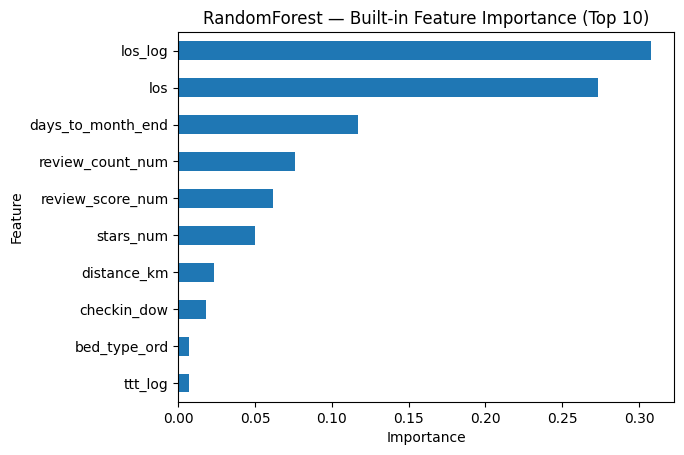

In [51]:
# RandomForest — Built-in feature_importances_

rf_cfg = rf_best_cfg if "rf_best_cfg" in globals() else {"n_estimators": 400, "max_depth": None, "random_state": RANDOM_STATE}

rf_fi = RandomForestRegressor(
    n_estimators=rf_cfg.get("n_estimators", 400),
    max_depth=rf_cfg.get("max_depth", None),
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_fi.fit(X_TRAIN_FI, y_TRAIN_FI)

rf_builtin = topk_importance(rf_fi.feature_importances_, X_TRAIN_FI.columns, k=10)
display(rf_builtin)
plot_topk(rf_builtin, "RandomForest — Built-in Feature Importance (Top 10)")


RandomForest — Method 2: Permutation importance

los_log                     0.424891
los                         0.363124
days_to_month_end           0.256956
stars_num                   0.191758
review_score_num            0.187245
review_count_num            0.139581
distance_km                 0.047682
checkin_dow                 0.030154
cancellation_cat_unknown    0.017638
bed_type_ord                0.015036
dtype: float64

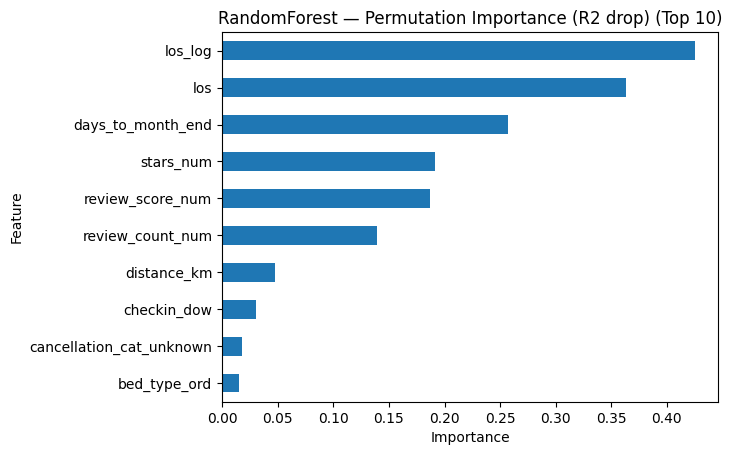

In [52]:
PERM_SAMPLE = 1500 
X_test_perm = X_TEST_FI.sample(n=min(PERM_SAMPLE, len(X_TEST_FI)), random_state=RANDOM_STATE)
y_test_perm = y_TEST_FI.loc[X_test_perm.index]

perm_rf = permutation_importance(
    rf_fi, X_test_perm, y_test_perm,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=-1
)

rf_perm_top = topk_importance(perm_rf.importances_mean, X_TEST_FI.columns, k=10)
display(rf_perm_top)
plot_topk(rf_perm_top, "RandomForest — Permutation Importance (R2 drop) (Top 10)")


GradientBoosting — Method 1: built-in feature_importances

los                  0.363061
los_log              0.264861
days_to_month_end    0.120389
review_count_num     0.074331
review_score_num     0.053924
stars_num            0.045252
distance_km          0.018409
ttt_x_los            0.014570
checkin_dow          0.010876
bed_type_ord         0.008776
dtype: float64

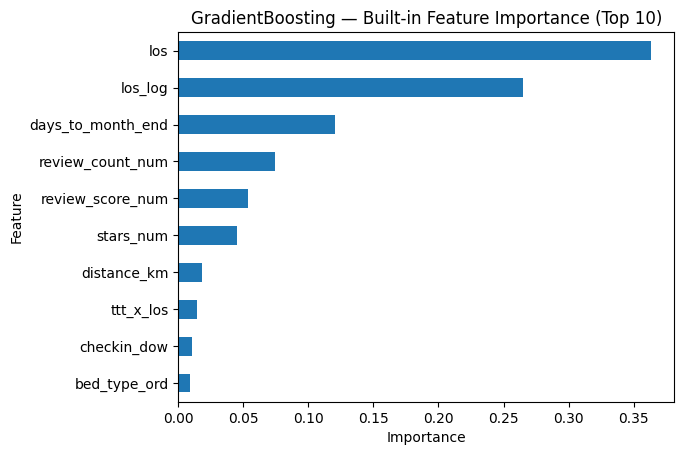

In [53]:
# GradientBoosting — Built-in feature_importances_

gbr_cfg = gbr_best_cfg if "gbr_best_cfg" in globals() else {"n_estimators": 200, "max_depth": 3, "random_state": RANDOM_STATE}

gbr_fi = GradientBoostingRegressor(
    n_estimators=gbr_cfg.get("n_estimators", 200),
    max_depth=gbr_cfg.get("max_depth", 3),
    random_state=RANDOM_STATE
)

gbr_fi.fit(X_TRAIN_FI, y_TRAIN_FI)

gbr_builtin = topk_importance(gbr_fi.feature_importances_, X_TRAIN_FI.columns, k=10)
display(gbr_builtin)
plot_topk(gbr_builtin, "GradientBoosting — Built-in Feature Importance (Top 10)")


GradientBoosting — Method 2: Permutation importance

los                  0.380777
los_log              0.285350
days_to_month_end    0.180533
review_score_num     0.140005
review_count_num     0.135252
stars_num            0.071370
distance_km          0.037504
ttt_x_los            0.031295
bed_type_ord         0.023745
checkin_dow          0.011730
dtype: float64

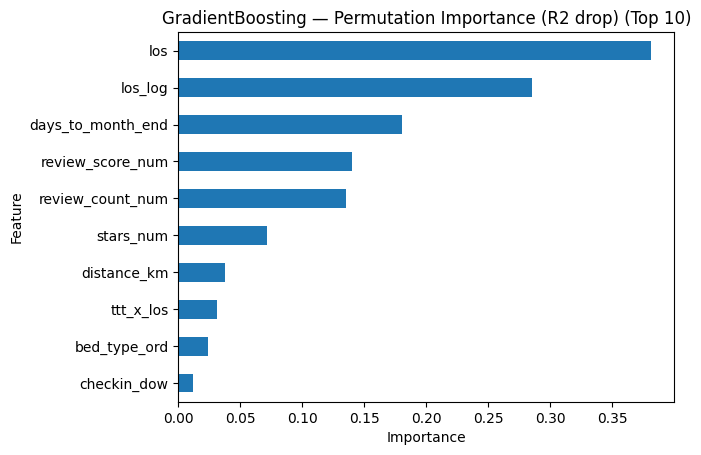

In [54]:
X_test_perm = X_TEST_FI.sample(n=min(PERM_SAMPLE, len(X_TEST_FI)), random_state=RANDOM_STATE)
y_test_perm = y_TEST_FI.loc[X_test_perm.index]

perm_gbr = permutation_importance(
    gbr_fi, X_test_perm, y_test_perm,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=-1
)

gbr_perm_top = topk_importance(perm_gbr.importances_mean, X_TEST_FI.columns, k=10)
display(gbr_perm_top)
plot_topk(gbr_perm_top, "GradientBoosting — Permutation Importance (R2 drop) (Top 10)")


# Task 5
In this task we evaluate the effect of different normalization/scaling methods on model performance.
We compare no scaling vs StandardScaler vs MinMaxScaler vs RobustScaler for scale-sensitive models.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


if "X_train_fe" in globals():
    X_TRAIN_SC, y_TRAIN_SC = X_train_fe, y_train_fe
    X_TEST_SC,  y_TEST_SC  = X_test_fe,  y_test_fe
    scaling_dataset_name = "ENGINEERED"
elif "X_train_imp" in globals():
    X_TRAIN_SC, y_TRAIN_SC = X_train_imp, y_train
    X_TEST_SC,  y_TEST_SC  = X_test_imp,  y_test
    scaling_dataset_name = "IMPUTED"
else:
    assert "X_train" in globals() and "X_test" in globals(), "No train/test split found"
    X_TRAIN_SC, y_TRAIN_SC = X_train, y_train
    X_TEST_SC,  y_TEST_SC  = X_test,  y_test
    scaling_dataset_name = "BASIC (fallback)"

print("dataset:", scaling_dataset_name)
print("Train:", X_TRAIN_SC.shape, "Test:", X_TEST_SC.shape)

def regression_metrics(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

def eval_pipeline(name, pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)

    m_tr = regression_metrics(y_train, pred_tr)
    m_te = regression_metrics(y_test, pred_te)

    return {
        "model": name,
        **{f"train_{k}": v for k, v in m_tr.items()},
        **{f"test_{k}": v for k, v in m_te.items()},
    }

scalers = {
    "none": None,
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}


dataset: ENGINEERED
Train: (60624, 29) Test: (25982, 29)


# SVR scaling comparison

SVR is highly sensitive to feature scaling, so we compare different scalers using the same SVR hyperparameters.

In [56]:
from sklearn.svm import SVR

svr_base = SVR(C=30.0, epsilon=0.1, kernel="rbf", gamma="scale")

svr_rows = []
for scaler_name, scaler in scalers.items():
    if scaler is None:
        pipe = Pipeline([("svr", svr_base)])
    else:
        pipe = Pipeline([("scaler", scaler), ("svr", svr_base)])

    row = eval_pipeline(f"SVR_RBF__{scaler_name}", pipe, X_TRAIN_SC, y_TRAIN_SC, X_TEST_SC, y_TEST_SC)
    svr_rows.append(row)

svr_results = pd.DataFrame(svr_rows).sort_values("test_RMSE").reset_index(drop=True)
display(svr_results)


,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,SVR_RBF__robust,0.792731,102.441740,31502.456774,177.489315,0.792962,103.126399,31472.416851,177.404670
1,SVR_RBF__standard,0.786011,105.031953,32523.947849,180.343971,0.786742,105.931714,32418.013486,180.050031
2,SVR_RBF__minmax,0.746192,119.713953,38575.909259,196.407508,0.748830,119.957499,38181.163074,195.400008
3,SVR_RBF__none,0.109326,288.136033,135372.270788,367.929709,0.110461,288.456491,135221.547787,367.724826


# KNN scaling comparison

KNN uses distance between samples, therefore scaling can drastically change performance.

In [57]:
from sklearn.neighbors import KNeighborsRegressor

knn_base = KNeighborsRegressor(n_neighbors=25, weights="distance")

knn_rows = []
for scaler_name, scaler in scalers.items():
    if scaler is None:
        pipe = Pipeline([("knn", knn_base)])
    else:
        pipe = Pipeline([("scaler", scaler), ("knn", knn_base)])

    row = eval_pipeline(f"KNN__{scaler_name}", pipe, X_TRAIN_SC, y_TRAIN_SC, X_TEST_SC, y_TEST_SC)
    knn_rows.append(row)

knn_results = pd.DataFrame(knn_rows).sort_values("test_RMSE").reset_index(drop=True)
display(knn_results)


,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,KNN__robust,0.999967,0.057222,5.036144,2.244135,0.939059,44.806247,9263.771030,96.248486
1,KNN__standard,0.999967,0.057218,5.036144,2.244135,0.926559,50.417092,11163.982871,105.659750
2,KNN__minmax,0.999967,0.057309,5.036154,2.244138,0.921239,52.303366,11972.668837,109.419691
3,KNN__none,0.999967,0.057194,5.036144,2.244135,0.897485,62.343010,15583.602207,124.834299


In [58]:
# Task 5 — Register best Scaling candidates (SVR + KNN)

from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Best SVR scaling (from svr_results)
svr_sorted = svr_results.sort_values("test_RMSE", ascending=True).reset_index(drop=True)
best_svr_model_label = str(svr_sorted.loc[0, "model"])
best_svr_scaler_key  = best_svr_model_label.split("__")[-1] # "standard"/"minmax"/"robust"/"none"

svr_scaler = scalers.get(best_svr_scaler_key, None)
if svr_scaler is None:
    best_svr_pipe = Pipeline([("svr", clone(svr_base))])
else:
    best_svr_pipe = Pipeline([("scaler", clone(svr_scaler)), ("svr", clone(svr_base))])

best_svr_pipe.fit(X_TRAIN_SC, y_TRAIN_SC)

register_candidate(
    f"{best_svr_model_label} (Scaling)",
    best_svr_pipe,
    X_TEST_SC,
    y_TEST_SC,
    notes=f"Best SVR scaling on {scaling_dataset_name}"
)

# Best KNN scaling (from knn_results)
knn_sorted = knn_results.sort_values("test_RMSE", ascending=True).reset_index(drop=True)
best_knn_model_label = str(knn_sorted.loc[0, "model"])
best_knn_scaler_key  = best_knn_model_label.split("__")[-1] # "standard"/"minmax"/"robust"/"none"

knn_scaler = scalers.get(best_knn_scaler_key, None)
if knn_scaler is None:
    best_knn_pipe = Pipeline([("knn", clone(knn_base))])
else:
    best_knn_pipe = Pipeline([("scaler", clone(knn_scaler)), ("knn", clone(knn_base))])

best_knn_pipe.fit(X_TRAIN_SC, y_TRAIN_SC)

register_candidate(
    f"{best_knn_model_label} (Scaling)",
    best_knn_pipe,
    X_TEST_SC,
    y_TEST_SC,
    notes=f"Best KNN scaling on {scaling_dataset_name}"
)

display(candidates_summary())


Registered: SVR_RBF__robust (Scaling) | RMSE=177.4047 | R²=0.7930
Registered: KNN__robust (Scaling) | RMSE=96.2485 | R²=0.9391


,name,rmse_test,r2_test,notes
0,RandomForestRegressor (FeatureEngineering),70.231437,0.967552,FE winner after Task 3
1,RandomForestRegressor (Task2),71.622711,0.966254,
2,KNN__robust (Scaling),96.248486,0.939059,Best KNN scaling on ENGINEERED
3,DecisionTreeRegressor (Task2),103.649955,0.929326,
4,GradientBoostingRegressor (Task2),163.981350,0.823108,
5,GaussianProcessRegressor (Task2),169.200996,0.811668,
6,SVR_RBF__robust (Scaling),177.404670,0.792962,Best SVR scaling on ENGINEERED
7,LinearRegression (Task2),228.354849,0.656964,
8,SVR_RBF (Task2),396.329838,-0.033315,


## Normalization / Scaling Experiments

Some model families are highly sensitive to feature scale (especially kernel and distance-based methods). We tested multiple scaling strategies and compared Train/Test performance.

### SVR (RBF) scaling (ENGINEERED dataset)
- **RobustScaler:** Test R² = **0.792962**, Test RMSE = **177.4047** (best SVR scaling)
- StandardScaler: Test R² = **0.786742**, Test RMSE = **180.0500**
- MinMaxScaler: Test R² = **0.748830**, Test RMSE = **195.4000**
- No scaling: Test R² = **0.110461**, Test RMSE = **367.7248**

**Conclusion (SVR):** Scaling is mandatory; without scaling, SVR collapses (R²≈0.11).

### KNN scaling (ENGINEERED dataset)
- **RobustScaler:** Test R² = **0.939059**, Test RMSE = **96.2485** (best KNN scaling)
- StandardScaler: Test R² = **0.926559**, Test RMSE = **105.6598**
- MinMaxScaler: Test R² = **0.921239**, Test RMSE = **109.4197**
- No scaling: Test R² = **0.897485**, Test RMSE = **124.8343**

**Important note:** KNN shows extreme Train fit (Train R²≈0.99997) alongside weaker Test performance, which indicates overfitting / memorization behavior typical for small-k KNN in high-dimensional feature spaces.

# Task 6

We train two different neural network architectures:

A baseline MLP that uses only the engineered numeric/one-hot features.

An MLP that additionally learns an embedding vector per hotel (hotel identity), which may capture hotel-specific pricing patterns.

We evaluate both networks using R², MAE, MSE, RMSE and plot a residual plot on the test set.

In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Required inputs
assert "engineered_df_model" in globals(), "engineered_df_model not found. Run Task 6 table-building first."
assert "df_no_out_all" in globals(), "df_no_out_all not found. Run Stage B on combined first."

TARGET_COL = "price_usd"

# Start from engineered features table
df_nn = engineered_df_model.copy()

# Bring hotel name from df_no_out_all (aligned by index)
assert "name" in df_no_out_all.columns, "'name' is missing from df_no_out_all (Stage B output)."
name_series = df_no_out_all.loc[df_nn.index, "name"].fillna("UNKNOWN_HOTEL").astype(str)

# Source: prefer engineered_df_model if exists, else take from df_no_out_all
if "source" in df_nn.columns:
    source_series = df_nn["source"].astype(str)
else:
    assert "source" in df_no_out_all.columns, "'source' missing from df_no_out_all."
    source_series = df_no_out_all.loc[df_nn.index, "source"].astype(str)

# Create hotel_id
hotel_key = source_series + "::" + name_series
hotel_to_id = {h: i for i, h in enumerate(hotel_key.unique())}
hotel_id_full = hotel_key.map(hotel_to_id).astype(int)

# Target + clean
assert TARGET_COL in df_nn.columns, f"{TARGET_COL} missing from engineered_df_model."
df_nn = df_nn.dropna(subset=[TARGET_COL]).replace([np.inf, -np.inf], np.nan).copy()

y = df_nn[TARGET_COL].astype(float)

# Features: drop target + metadata
drop_cols = [TARGET_COL]
for c in ["source", "checkin", "name", "card_text", "url", "hotel_id"]:
    if c in df_nn.columns:
        drop_cols.append(c)

X = df_nn.drop(columns=drop_cols, errors="ignore")

# Impute numeric features
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)

# Align hotel_id + source to the final X/y index
hotel_id = pd.Series(hotel_id_full, index=df_nn.index).loc[X_imp.index].to_numpy(dtype=np.int64)
src_nn   = source_series.loc[X_imp.index]

# Split (stratify by source)
X_train, X_test, y_train, y_test, hid_train, hid_test, src_train, src_test = train_test_split(
    X_imp, y, hotel_id, src_nn,
    test_size=0.30, random_state=7, stratify=src_nn
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Unique hotels:", len(np.unique(hotel_id)))
print("Test source counts:", src_test.value_counts().to_dict())


X_train: (60624, 29) X_test: (25982, 29)
Unique hotels: 643
Test source counts: {'booking': 13111, 'expedia': 12871}


In [60]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

class HotelPriceDataset(Dataset):
    def __init__(self, X_df, y_ser, hotel_ids):
        self.X = torch.tensor(X_df.values, dtype=torch.float32)
        self.y = torch.tensor(y_ser.values, dtype=torch.float32).view(-1, 1)
        self.hid = torch.tensor(hotel_ids, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.hid[idx]

BATCH_SIZE = 256

train_ds = HotelPriceDataset(X_train, y_train, hid_train)
test_ds  = HotelPriceDataset(X_test,  y_test,  hid_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train.shape[1]
N_HOTELS  = int(np.max(hotel_id)) + 1
print("INPUT_DIM:", INPUT_DIM, "| N_HOTELS:", N_HOTELS)


Device: cpu
INPUT_DIM: 29 | N_HOTELS: 643


### NN1 — Baseline MLP (ReLU)

Architecture A (baseline): deeper MLP with ReLU + Dropout.

In [61]:
class NN1_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

nn1 = NN1_MLP(INPUT_DIM).to(DEVICE)
nn1


NN1_MLP(
  (net): Sequential(
    (0): Linear(in_features=29, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.15, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

Training loop + evaluation utilities

We train using MSE loss and Adam optimizer, and evaluate on the test set.

In [62]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def train_model_plain(model, train_dl, test_dl, epochs=15, lr=1e-3):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        for xb, yb, _hid in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(yb)

        if ep in [1, 5, 10, epochs]:
            print(f"Epoch {ep}/{epochs} | train MSE: {total/len(train_dl.dataset):.4f}")

def predict_plain(model, dl):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb, _hid in dl:
            xb = xb.to(DEVICE)
            pred = model(xb).cpu().numpy().reshape(-1)
            ys.append(yb.numpy().reshape(-1))
            ps.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred

def metrics_dict(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "model": name,
        "test_R2": r2_score(y_true, y_pred),
        "test_MAE": mean_absolute_error(y_true, y_pred),
        "test_MSE": mse,
        "test_RMSE": np.sqrt(mse),
    }

def residual_plot_np(y_true, y_pred, title):
    resid = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, resid, s=6, alpha=0.35)
    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Predicted price (USD)")
    plt.ylabel("Residual (true - pred)")
    plt.tight_layout()
    plt.show()


Epoch 1/15 | train MSE: 212774.4886
Epoch 5/15 | train MSE: 63466.2899
Epoch 10/15 | train MSE: 56999.9190
Epoch 15/15 | train MSE: 53030.0598


,model,test_R2,test_MAE,test_MSE,test_RMSE
0,NN1_MLP(ReLU),0.691617,153.052032,46878.222656,216.513793


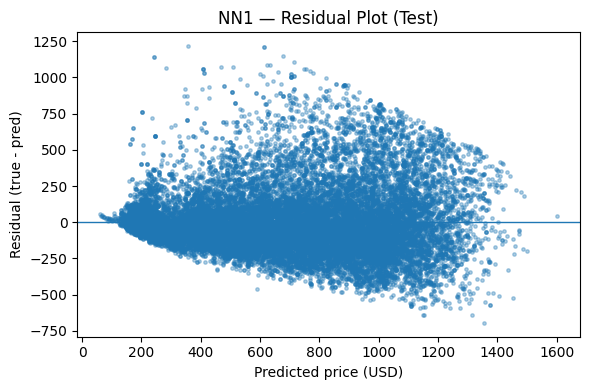

In [63]:
train_model_plain(nn1, train_dl, test_dl, epochs=15, lr=1e-3)

y_true_1, y_pred_1 = predict_plain(nn1, test_dl)
nn1_metrics = metrics_dict(y_true_1, y_pred_1, "NN1_MLP(ReLU)")
display(pd.DataFrame([nn1_metrics]))

residual_plot_np(y_true_1, y_pred_1, "NN1 — Residual Plot (Test)")


### NN2 — MLP + Hotel Embedding (LeakyReLU)

Architecture B: uses a learned embedding per hotel ID + a different activation (LeakyReLU).


In [64]:
class NN2_MLP_HotelEmbedding(nn.Module):
    def __init__(self, input_dim, n_hotels, emb_dim=16):
        super().__init__()
        self.emb = nn.Embedding(n_hotels, emb_dim)

        self.net = nn.Sequential(
            nn.Linear(input_dim + emb_dim, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.20),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x, hid):
        e = self.emb(hid)
        z = torch.cat([x, e], dim=1)
        return self.net(z)

nn2 = NN2_MLP_HotelEmbedding(INPUT_DIM, N_HOTELS, emb_dim=16).to(DEVICE)
nn2


NN2_MLP_HotelEmbedding(
  (emb): Embedding(643, 16)
  (net): Sequential(
    (0): Linear(in_features=45, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
)

Epoch 1/15 | train MSE: 241316.7021
Epoch 5/15 | train MSE: 36806.0285
Epoch 10/15 | train MSE: 24971.6770
Epoch 15/15 | train MSE: 21446.2691


,model,test_R2,test_MAE,test_MSE,test_RMSE
0,NN2_MLP+Embedding(LeakyReLU),0.876736,89.418846,18737.78125,136.886016


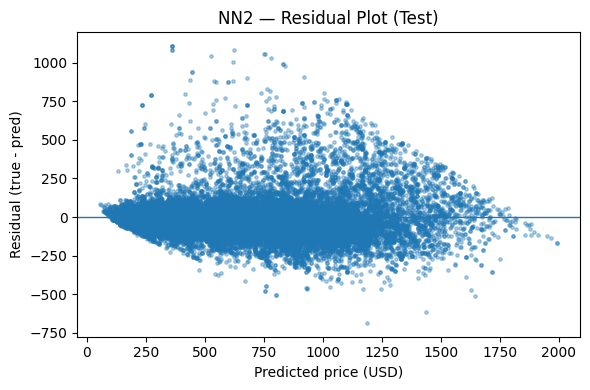

In [65]:
def train_model_emb(model, train_dl, epochs=15, lr=1e-3):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        for xb, yb, hid in train_dl:
            xb, yb, hid = xb.to(DEVICE), yb.to(DEVICE), hid.to(DEVICE)
            pred = model(xb, hid)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(yb)

        if ep in [1, 5, 10, epochs]:
            print(f"Epoch {ep}/{epochs} | train MSE: {total/len(train_dl.dataset):.4f}")

def predict_emb(model, dl):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb, hid in dl:
            xb, hid = xb.to(DEVICE), hid.to(DEVICE)
            pred = model(xb, hid).cpu().numpy().reshape(-1)
            ys.append(yb.numpy().reshape(-1))
            ps.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred

train_model_emb(nn2, train_dl, epochs=15, lr=1e-3)

y_true_2, y_pred_2 = predict_emb(nn2, test_dl)
nn2_metrics = metrics_dict(y_true_2, y_pred_2, "NN2_MLP+Embedding(LeakyReLU)")
display(pd.DataFrame([nn2_metrics]))

residual_plot_np(y_true_2, y_pred_2, "NN2 — Residual Plot (Test)")


We compare NN1 vs NN2 on the same test set.

In [66]:
pd.DataFrame([nn1_metrics, nn2_metrics]).sort_values("test_RMSE").reset_index(drop=True)

,model,test_R2,test_MAE,test_MSE,test_RMSE
0,NN2_MLP+Embedding(LeakyReLU),0.876736,89.418846,18737.781250,136.886016
1,NN1_MLP(ReLU),0.691617,153.052032,46878.222656,216.513793


## Neural Networks

We trained two neural-network architectures on the ENGINEERED feature set (29 numeric features), with **643 unique hotels**.

### NN1: MLP (ReLU)
- Test R² = **0.691617**
- Test MAE = **153.052**
- Test RMSE = **216.5138**

This is comparable to the classic SVR baseline (R²≈0.688) but substantially worse than the tree ensembles.

### NN2: MLP + Hotel Embedding (LeakyReLU)
We added a learned embedding for `hotel_id` (Embedding(643, 16)) to capture hotel-specific latent effects not fully represented by the structured card features.

- Test R² = **0.876736**
- Test MAE = **89.419**
- Test RMSE = **136.8860**

**Interpretation:**  
The embedding significantly improves performance versus the plain MLP, suggesting that hotel identity carries strong predictive information (consistent price “level” per hotel).

**Caveat (important):**  
With a random split, the same hotel can appear in both Train and Test, so an embedding can partially memorize hotel identity. Therefore, NN2 results should be interpreted carefully (they may represent an optimistic upper bound under this split strategy).

## Final best model

In [67]:
final_best, final_scoreboard = pick_final_best()
display(final_scoreboard)

final_best_model = final_best["model"]
final_best_X_test = final_best["X_test"]
final_best_y_test = final_best["y_test"]
final_best_name = final_best["name"]


FINAL BEST: RandomForestRegressor (FeatureEngineering) | RMSE: 70.23143709386095


,name,rmse_test,r2_test,notes
0,RandomForestRegressor (FeatureEngineering),70.231437,0.967552,FE winner after Task 3
1,RandomForestRegressor (Task2),71.622711,0.966254,
2,KNN__robust (Scaling),96.248486,0.939059,Best KNN scaling on ENGINEERED
3,DecisionTreeRegressor (Task2),103.649955,0.929326,
4,GradientBoostingRegressor (Task2),163.981350,0.823108,
5,GaussianProcessRegressor (Task2),169.200996,0.811668,
6,SVR_RBF__robust (Scaling),177.404670,0.792962,Best SVR scaling on ENGINEERED
7,LinearRegression (Task2),228.354849,0.656964,
8,SVR_RBF (Task2),396.329838,-0.033315,


## Stage C — Final Model Comparison (Best Overall)

Across all experiments (baseline models, feature engineering, scaling tests, and neural networks), the best model is:

**RandomForestRegressor (FeatureEngineering)**  
- **Test RMSE = 70.2314**
- **Test R² = 0.967552**

Key comparisons:
- Next-best classic ML (RandomForest baseline): RMSE **71.6227**, R² **0.966254**
- Best scaling-based alternative (KNN Robust): RMSE **96.2485**, R² **0.939059**
- Best neural model (NN2 + embedding): RMSE **136.8860**, R² **0.876736**

**Conclusion:** The final winner is still the engineered-feature RandomForest, which provides the best generalization on this split and clearly outperforms both the neural baselines and other classical regressors.

# Task 7

Best Model: Distribution of R² Across Hotels (Per-Hotel)

Hotels with >=2 test samples: 432


C:\Users\Roni\AppData\Local\Temp\ipykernel_14572\4068960969.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_hotel = per_row.groupby("hotel_id").apply(r2_if_possible).dropna()


count    432.000000
mean      -0.446003
std       12.766195
min     -220.229063
25%        0.823208
50%        0.953548
75%        0.986744
max        0.999990
dtype: float64

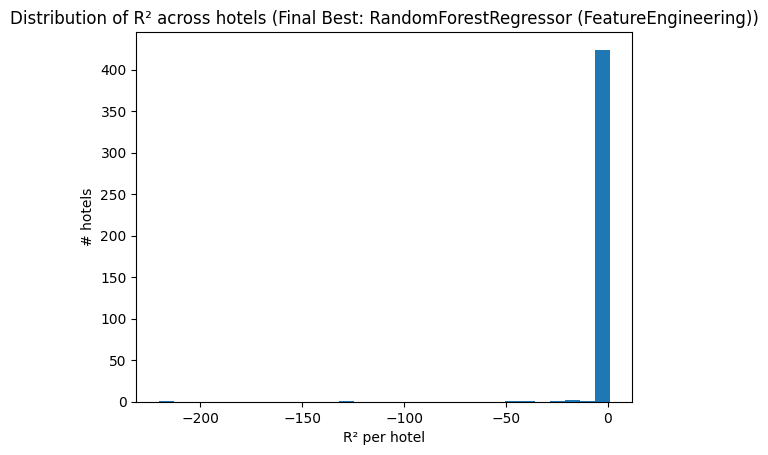

In [76]:
# Task 7 — R² distribution across hotels (Final Best Model)

from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y_pred_best = final_best_model.predict(final_best_X_test)

hotel_id_test = feature_df_all.loc[final_best_X_test.index, "hotel_id"]

per_row = pd.DataFrame({
    "hotel_id": hotel_id_test.values,
    "y_true": pd.Series(final_best_y_test).values,
    "y_pred": pd.Series(y_pred_best).values,
})

def r2_if_possible(g):
    if len(g) < 2:
        return np.nan
    return r2_score(g["y_true"], g["y_pred"])

r2_by_hotel = per_row.groupby("hotel_id").apply(r2_if_possible).dropna()

print("Hotels with >=2 test samples:", len(r2_by_hotel))
display(r2_by_hotel.describe())

plt.figure()
plt.hist(r2_by_hotel.values, bins=30)
plt.title(f"Distribution of R² across hotels (Final Best: {final_best_name})")
plt.xlabel("R² per hotel")
plt.ylabel("# hotels")
plt.show()


## Per-hotel R² Distribution (Best Model)

To understand whether performance is consistent across hotels (and not only strong on average), we computed **R² per hotel** on the Test set for hotels with at least 2 Test samples.

- Hotels with ≥2 test samples: **432**
- Per-hotel R² summary:
  - mean = **−0.4460**
  - std  = **12.7662**
  - min  = **−220.2291**
  - 25%  = **0.8232**
  - 50% (median) = **0.9535**
  - 75%  = **0.9867**
  - max  = **0.99999**

**Interpretation:**  
The **median per-hotel R² (~0.954)** is very strong, meaning the model performs well for a large fraction of hotels.  
However, the **mean becomes negative** because a small number of hotels have extremely negative R² (heavy-tail failures), which can happen when:
- a hotel has very few test points (even ≥2 can still be unstable),
- the hotel’s pricing is highly volatile (promotions, availability effects),
- or the extracted features are insufficient for that hotel’s pricing behavior.


Future split sizes: train = 17649 test  = 68957


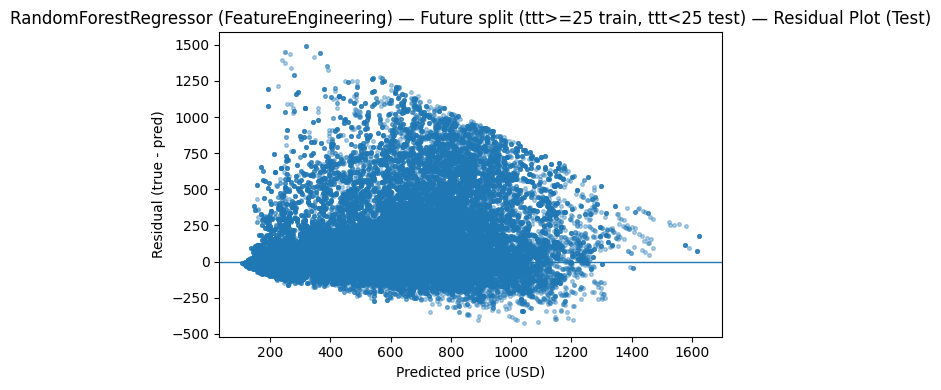

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,RandomForestRegressor (FeatureEngineering) — F...,0.995397,11.849544,617.972888,24.85906,0.555187,162.672286,69605.502503,263.828548


In [79]:
# Task 8 — Future split (Train: ttt>=25, Test: ttt<25) on ENGINEERED features

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.base import clone

# Required inputs (these exist in your notebook)
assert "engineered_df_model" in globals(), "engineered_df_model missing. Run the Stage C FE table-building cell."
assert "final_best_model" in globals(), "final_best_model missing. Pick the final best model first."
assert "eval_train_test" in globals(), "eval_train_test missing."

TARGET_COL = "price_usd"
TTT_COL = "ttt"

# 1) Start from the engineered table (includes engineered features)
dfm = engineered_df_model.dropna(subset=[TARGET_COL]).replace([np.inf, -np.inf], np.nan).copy()
assert TTT_COL in dfm.columns, "ttt column is missing from engineered_df_model."
assert "source" in dfm.columns, "source is missing from engineered_df_model."

# 2) Build the feature matrix exactly like Task 3 (drop target + metadata)
drop_cols = [TARGET_COL, "source"]
if "checkin" in dfm.columns:
    drop_cols.append("checkin")

X_raw = dfm.drop(columns=drop_cols)
y_all = dfm[TARGET_COL].astype(float)

# 3) Future masks (ignore rows where ttt is NaN)
valid_ttt = dfm[TTT_COL].notna()
train_mask = valid_ttt & (dfm[TTT_COL] >= 25)
test_mask  = valid_ttt & (dfm[TTT_COL] <  25)

print("Future split sizes:",
      "train =", int(train_mask.sum()),
      "test  =", int(test_mask.sum()))

X_train_raw = X_raw.loc[train_mask]
y_train_fut = y_all.loc[train_mask]

X_test_raw  = X_raw.loc[test_mask]
y_test_fut  = y_all.loc[test_mask]

# 4) Median imputation fitted ONLY on the future-train set (same policy as Task 3)
imp_fut = SimpleImputer(strategy="median")
X_train_fut = pd.DataFrame(imp_fut.fit_transform(X_train_raw), columns=X_raw.columns, index=X_train_raw.index)
X_test_fut  = pd.DataFrame(imp_fut.transform(X_test_raw),    columns=X_raw.columns, index=X_test_raw.index)

# 5) Fit+evaluate a fresh copy of the final best model on this split
model_future = clone(final_best_model)

row_future, _, _ = eval_train_test(
    model_future,
    X_train_fut, y_train_fut,
    X_test_fut,  y_test_fut,
    model_name=f"{final_best_name} — Future split (ttt>=25 train, ttt<25 test)",
    plot_residuals=True
)

display(pd.DataFrame([row_future]))


## Future Generalization Test (TTT≥25 → TTT<25)

To simulate a realistic forecasting setup, we trained on “earlier booking” searches and tested on “closer-to-checkin” searches:

- **Train:** TTT ≥ 25  (train size = **17,649**)  
- **Test:**  TTT < 25  (test size  = **68,957**)  

Using the best model (**RandomForestRegressor (FeatureEngineering)**):

### Performance
- **Train:** R² = **0.995397**, RMSE = **24.8591**
- **Test:**  R² = **0.555187**, RMSE = **263.8285**, MAE = **162.6723**

**Interpretation:**  
This is a major drop compared to the random split (where Test R² ≈ **0.9676** and RMSE ≈ **70.23**).  
It strongly suggests a **distribution shift**: the relationship between the available card features and price changes when we move from “far from check-in” to “close to check-in”. Last-minute pricing can be affected by demand spikes, limited inventory, and pricing policies that are not fully captured by the scraped features.

**Conclusion:**  
The model is excellent under random mixing but generalizes much less to a forward-looking TTT shift, which is closer to a real “future prediction” scenario.

## Stage C — Why RandomForest Wins + Booking vs Expedia Differences

### Why RandomForestRegressor is the best-performing classical ML model
RandomForest achieves the strongest generalization on the random 70/30 split, outperforming both linear and kernel-based methods:

- **RandomForestRegressor (Test):** R² = **0.960586**, MAE = **39.706**, RMSE = **77.404**
- **LinearRegression (Test):** R² = **0.656964**, MAE = **163.896**, RMSE = **228.355**
- **SVR (RBF) (Test):** R² = **0.687946**, MAE = **135.834**, RMSE = **217.799**
- **DecisionTreeRegressor (Test):** R² = **0.837099**, MAE = **99.552**, RMSE = **157.363**

**Interpretation:**  
The large gap between LinearRegression (R²≈0.657) and RandomForest (R²≈0.961) indicates that hotel pricing depends on **non-linear relationships and feature interactions** (e.g., stars × neighborhood, review signals × distance, cancellation policy effects). RandomForest is also relatively robust to noisy features and does not require scaling, which helps on real-world scraped data.

### Booking vs Expedia: the same model behaves very differently by source
When we evaluate the *same* RandomForest model separately per source, we see a clear discrepancy:

- **Booking (RandomForest):** R² = **0.986710**, RMSE = **44.779**, MAE = **22.167**
- **Expedia (RandomForest):** R² = **0.934350**, RMSE = **100.260**, MAE = **57.573**

**What this suggests:**  
Expedia is **harder to predict** from the available card-level features. Likely reasons include:
1) **Feature availability and consistency:** result cards may expose fewer or less consistent attributes (e.g., bed details, distance, room-type formatting), weakening the model signal.  
2) **Price presentation differences:** taxes/fees inclusion and deal logic may differ by site, increasing noise in `price_usd`.  
3) **Different property mix / ranking behavior:** the distribution of hotels shown and the default ranking logic may differ by platform for the same query parameters.

**Conclusion:**  
RandomForest wins because it captures complex non-linear structure and interactions, but the per-source gap shows that *data quality and feature richness* (especially on Expedia) strongly affect achievable accuracy.